In [68]:
import os 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [69]:
print(os.getcwd())

/home/aantar2


In [70]:
import os
print(os.cpu_count())

20


In [71]:
import time
notebook_start_time = time.time()

In [72]:
data_path = "/home/dsemchin/COMIND/experiments/2026_07_02_PPMI_K82_cold_gs_lowscalar_betaclin_betaall/PPMI_deviation_scores_with_beta_proba_per_timepoint.csv"
#data_path = "/home/dsemchin/data/data_ppmi_pd_with_best_model_subject_cols_with_subtype_probas.csv"

time_col = "time"

# Primary ordered NSD outcome
cat_levels = [
    "Stage 2",
    "Stage 3",
    "Stage 4",
    "Stage 5+"
]

df_all = pd.read_csv(data_path)

# Clinical predictors
CLINICAL_COLS = [
    "MCATOT",
    "TD_score",
    "PIGD_score",
]

# Four continuous COMIND beta values
BASELINE_BETA_COLS = [
    "beta_0",
    "beta_1",
    "beta_2",
    "beta_3",
]

LONG_BETA_COLS = [
    "beta_0_long",
    "beta_1_long",
    "beta_2_long",
    "beta_3_long",
]

# All later model code that uses BETA_COLS
# will now use the longitudinal versions.
BETA_COLS = LONG_BETA_COLS

# Complete four-component static subtype-probability vector
PROBA_COLS = [
    "proba_0",
    "proba_1",
    "proba_2",
    "proba_3",
]

# Three nonredundant components used as model predictors.
# subtype_proba_0 remains in the dataframe and is used in checks.
PROBA_FEATURES = [
    "proba_1",
    "proba_2",
    "proba_3",
]
# 68 residualized cortical-thickness variables
CORTICAL_RESID_COLS = [
    col for col in df_all.columns
    if col.startswith(("L_", "R_"))
    and col.endswith("_thickavg_resid")
]

# 16 residualized subcortical-volume variables
SUBCORTICAL_RESID_COLS = [
    col for col in [
        "Left-Lateral-Ventricle_resid",
        "Right-Lateral-Ventricle_resid",
        "Left-Thalamus-Proper_resid",
        "Right-Thalamus-Proper_resid",
        "Left-Caudate_resid",
        "Right-Caudate_resid",
        "Left-Putamen_resid",
        "Right-Putamen_resid",
        "Left-Pallidum_resid",
        "Right-Pallidum_resid",
        "Left-Hippocampus_resid",
        "Right-Hippocampus_resid",
        "Left-Amygdala_resid",
        "Right-Amygdala_resid",
        "Left-Accumbens-area_resid",
        "Right-Accumbens-area_resid",
    ]
    if col in df_all.columns
]

IMAGING_RESID_COLS = (
    CORTICAL_RESID_COLS
    + SUBCORTICAL_RESID_COLS
)

# The ordinal models will receive the residuals directly.

IMAGING_FEATURES = IMAGING_RESID_COLS

print("Cortical residual columns:",len(CORTICAL_RESID_COLS))
print("Subcortical residual columns:",len(SUBCORTICAL_RESID_COLS))
print("Total imaging residual columns:",len(IMAGING_FEATURES))
if len(CORTICAL_RESID_COLS) != 68:
    raise ValueError(
        "Expected 68 cortical residual columns, "
        f"but found {len(CORTICAL_RESID_COLS)}."
    )
if len(SUBCORTICAL_RESID_COLS) != 16:
    raise ValueError(
        "Expected 16 subcortical residual columns, "
        f"but found {len(SUBCORTICAL_RESID_COLS)}."
    )
if len(IMAGING_FEATURES) != 84:
    raise ValueError(
        "Expected 84 total imaging residual columns, "
        f"but found {len(IMAGING_FEATURES)}."
    )

required_subtype_cols = BASELINE_BETA_COLS + PROBA_COLS

missing_subtype_cols = [
    col for col in required_subtype_cols
    if col not in df_all.columns
]

if missing_subtype_cols:
    raise ValueError(
        "Missing required four-subtype columns: "
        f"{missing_subtype_cols}"
    )

print("Four-subtype beta columns:", BASELINE_BETA_COLS)

print("Longitudinal beta columns used by models:", BETA_COLS)
print("Static probability-vector columns:", PROBA_COLS)

print("Original NSD_STAGE counts:")
print(df_all["NSD_STAGE"].value_counts(dropna=False))

Cortical residual columns: 68
Subcortical residual columns: 16
Total imaging residual columns: 84
Four-subtype beta columns: ['beta_0', 'beta_1', 'beta_2', 'beta_3']
Longitudinal beta columns used by models: ['beta_0_long', 'beta_1_long', 'beta_2_long', 'beta_3_long']
Static probability-vector columns: ['proba_0', 'proba_1', 'proba_2', 'proba_3']
Original NSD_STAGE counts:
NSD_STAGE
3          503
4          127
2b         123
Not NSD     45
NaN         31
5            8
2a           1
6            1
Name: count, dtype: int64


In [73]:
def build_ordinal_panel(df, feature_cols):

    panel_df = df.copy()
    panel_df["_original_row"] = np.arange(len(panel_df))

    # 1. Clean subject ID, split, and time
    panel_df["subj_id"] = pd.to_numeric(panel_df["subj_id"], errors="coerce")

    panel_df["model_split_best"] = (panel_df["model_split_best"].astype("string")
                                    .str.strip().str.lower())
    #Save original time in months for inspection.
    panel_df["time_months"] = pd.to_numeric(panel_df["time"], errors="coerce")

    #Model time in years.
    panel_df["time"] = panel_df["time_months"] / 12.0

    # Convert the original time-zero betas to numeric.
    panel_df[BASELINE_BETA_COLS] = (
        panel_df[BASELINE_BETA_COLS]
        .apply(pd.to_numeric, errors="coerce")
    )

# Create visit-specific beta values:
# baseline beta + elapsed time in years.
    for baseline_col, longitudinal_col in zip(
        BASELINE_BETA_COLS,
        LONG_BETA_COLS,
    ):
        panel_df[longitudinal_col] = (
            panel_df[baseline_col]
            + panel_df["time"]
        )
   
    # 2. Preserve the complete static probability vector.
    # Do not derive a hard subtype with argmax.
    panel_df[PROBA_COLS] = (
        panel_df[PROBA_COLS]
        .apply(pd.to_numeric, errors="coerce")
    )

    # 3. Create primary NSD outcome:
    #    Stage 2 < Stage 3 < Stage 4 < Stage 5+
    nsd_raw = (panel_df["NSD_STAGE"].astype("string").str.strip().str.lower()
               .str.replace(r"\.0$", "", regex=True))

    nsd_mapping = {"2": "Stage 2", "2a": "Stage 2", "2b": "Stage 2",
                   "3": "Stage 3", "4": "Stage 4", "5": "Stage 5+",
                   "6": "Stage 5+"}

    panel_df["NSD_group"] = nsd_raw.map(nsd_mapping)
    panel_df["NSD_ordered"] = pd.Categorical(panel_df["NSD_group"], categories=cat_levels, ordered=True)

    # Not NSD, genuinely missing stages, and unexpected labels
    # remain missing and will be excluded from the primary analysis.
    panel_df = panel_df.dropna(
        subset=["NSD_ordered"]
    ).copy()

# 4. Inspect repeated subject-time observations.
# Keep them because ON and OFF assessments at the same visit
# represent different medication states.
    duplicate_visits = panel_df[
        panel_df.duplicated(
            subset=["subj_id", "time"],
            keep=False
        )
    ].copy()

    print(
        "\nRows belo    nging to repeated subject-times:",
        len(duplicate_visits)
        )

    panel_df = panel_df.sort_values(
        ["subj_id", "time", "_original_row"]
    ).copy()

    # 7. Convert model predictors to numeric
    panel_df[feature_cols] = panel_df[feature_cols].apply(pd.to_numeric,errors="coerce")
    panel_df = panel_df.replace([np.inf, -np.inf],np.nan)

   
    # 8. Create the complete-case analysis cohort
    cols_needed = ["NSD_ordered", "subj_id","model_split_best"] + feature_cols
    rows_before_complete_case = len(panel_df)
    model_df = panel_df.dropna(subset=cols_needed).copy()

    print( "\nRows removed by complete-case filtering:",
            rows_before_complete_case - len(model_df))

    # Keep only Dan's train and validation splits.
    model_df = model_df[ model_df["model_split_best"].isin(["train", "val"])].copy()
    model_df = (model_df.sort_values(["subj_id", "time"]).drop(columns=["_original_row"], 
                                                               errors="ignore").reset_index(drop=True))


    # 9. Confirm subject-level split stability
    split_stability = (model_df.groupby("subj_id")["model_split_best"].nunique())

    overlapping_subjects = split_stability[split_stability > 1].index.tolist()

    if len(overlapping_subjects) > 0:
        raise ValueError(
            "Some subjects occur in both train and validation: "
            f"{overlapping_subjects}"
        )

    # 10. Separate training and validation data
    ord_train = model_df[model_df["model_split_best"] == "train"].copy()

    ord_val = model_df[model_df["model_split_best"] == "val"].copy()

        # Make sure every primary NSD level appears in training.
    observed_train_levels = set(ord_train["NSD_ordered"].dropna().astype(str))

    missing_train_levels = [
        level
        for level in cat_levels
        if level not in observed_train_levels
    ]

    if missing_train_levels:
        raise ValueError(
            "The following NSD categories are absent from training: "
            f"{missing_train_levels}"
        )

        # Restore the same ordered categories in both sets.
    ord_train["NSD_ordered"] = pd.Categorical(ord_train["NSD_ordered"], categories=cat_levels, ordered=True)

    ord_val["NSD_ordered"] = pd.Categorical(ord_val["NSD_ordered"], categories=cat_levels, ordered=True)

    return model_df, ord_train, ord_val, duplicate_visits

In [74]:
def add_pdstate_features(df):
    df = df.copy()

    # Standardize spelling while preserving actual missing values
    pdstate_clean = (
        df["PDSTATE"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    # Treat these representations as missing PDSTATE
    pdstate_clean = pdstate_clean.replace({
        "NAN": pd.NA,
        "NONE": pd.NA,
        "": pd.NA
    })

    # Missing PDSTATE becomes its own explicit category
    df["PDSTATE_clean"] = pdstate_clean.fillna("NA")

    valid_states = {"OFF", "ON", "NA"}
    unexpected_states = (
        set(df["PDSTATE_clean"].unique()) - valid_states
    )

    if unexpected_states:
        raise ValueError(
            f"Unexpected PDSTATE values: {unexpected_states}"
        )

    # OFF is the reference category
    df["pdstate_on"] = (
        df["PDSTATE_clean"] == "ON"
    ).astype(int)

    df["pdstate_na"] = (
        df["PDSTATE_clean"] == "NA"
    ).astype(int)

    return df

In [75]:
base_features = (
    CLINICAL_COLS
    + BETA_COLS
    + PROBA_COLS
    + IMAGING_FEATURES
    + ["time"]
)

In [76]:
print(df_all["split"].value_counts(dropna=False))

split_counts_per_subject = (
    df_all
    .groupby("subj_id")["split"]
    .nunique(dropna=True)
)

print(
    "\nSubjects appearing in more than one split:",
    (split_counts_per_subject > 1).sum(),
)
# Preserve the new names while creating the names
# expected by the existing ordinal notebook.
df_all["model_split_best"] = df_all["split"]
print(
    df_all["model_split_best"]
    .value_counts(dropna=False)
)

split
train    533
val      191
NaN      115
Name: count, dtype: int64

Subjects appearing in more than one split: 0
model_split_best
train    533
val      191
NaN      115
Name: count, dtype: int64


In [77]:
model_df, ord_train, ord_val, duplicate_visits = (
    build_ordinal_panel(
        df_all,
        base_features
    )
)

full_cats = pd.Index(cat_levels)
# Confirm that all longitudinal columns were created.
assert set(LONG_BETA_COLS).issubset(model_df.columns)

expected_long_betas = (
    model_df[BASELINE_BETA_COLS]
    .to_numpy(dtype=float)
    + model_df["time"]
    .to_numpy(dtype=float)[:, None]
)

observed_long_betas = (
    model_df[LONG_BETA_COLS]
    .to_numpy(dtype=float)
)

assert np.allclose(
    observed_long_betas,
    expected_long_betas,
    equal_nan=True,
)

display(
    model_df.loc[
        model_df["subj_id"] == 4020,
        (
            ["subj_id", "time"]
            + BASELINE_BETA_COLS
            + LONG_BETA_COLS
            + PROBA_COLS
        ),
    ]
)


Rows belo    nging to repeated subject-times: 226

Rows removed by complete-case filtering: 110


,subj_id,time,beta_0,beta_1,beta_2,beta_3,beta_0_long,beta_1_long,beta_2_long,beta_3_long,proba_0,proba_1,proba_2,proba_3
578,4020,0.0000,33.5934,31.1946,31.0768,31.9009,33.5934,31.1946,31.0768,31.9009,0.1746,0.3194,0.2311,0.2749
579,4020,1.0000,33.5934,31.1946,31.0768,31.9009,34.5934,32.1946,32.0768,32.9009,0.1735,0.3139,0.2532,0.2594
580,4020,2.0000,33.5934,31.1946,31.0768,31.9009,35.5934,33.1946,33.0768,33.9009,0.2093,0.3196,0.1988,0.2724
581,4020,4.0000,33.5934,31.1946,31.0768,31.9009,37.5934,35.1946,35.0768,35.9009,0.2302,0.3101,0.1899,0.2698


In [78]:
# Encode PDSTATE after model_df has been created
model_df = add_pdstate_features(model_df)

# Include subtype in the duplicate comparison.
# Ignore subtype_best entirely.
comparison_cols = (
    [
        "subj_id",
        "time",
        "PDSTATE_clean",
        "NSD_group",
        "model_split_best",
        "subtype",
    ]
    + CLINICAL_COLS
    + BETA_COLS
    + PROBA_COLS
    + IMAGING_FEATURES
)

rows_before = len(model_df)

model_df = (
    model_df
    .drop_duplicates(
        subset=comparison_cols,
        keep="first"
    )
    .sort_values(["subj_id", "time"])
    .reset_index(drop=True)
)

print(
    "Exact duplicate rows removed:",
    rows_before - len(model_df)
)

# Recreate train and validation AFTER removing exact duplicates
ord_train = model_df[
    model_df["model_split_best"] == "train"
].copy()

ord_val = model_df[
    model_df["model_split_best"] == "val"
].copy()

pdstate_cols = [
    "pdstate_on",
    "pdstate_na",
]

print("\nImaging-complete cohort:")

display(
    model_df
    .groupby("model_split_best")
    .agg(
        rows=("subj_id", "size"),
        subjects=("subj_id", "nunique")
    )
)

Exact duplicate rows removed: 0

Imaging-complete cohort:


,rows,subjects
model_split_best,,
train,488,114
val,165,165


In [79]:
print("\nFinal rows and subjects by split:")
print(
    model_df.groupby("model_split_best")
    .agg(
        rows=("subj_id", "size"),
        subjects=("subj_id", "nunique")
    )
)

print("\nNSD counts by split:")
print(
    pd.crosstab(
        model_df["model_split_best"],
        model_df["NSD_ordered"],
        margins=True,
        dropna=False
    )
)

print("\nTraining NSD counts:")
print(
    ord_train["NSD_ordered"]
    .value_counts()
    .reindex(cat_levels, fill_value=0)
)

print("\nValidation NSD counts:")
print(
    ord_val["NSD_ordered"]
    .value_counts()
    .reindex(cat_levels, fill_value=0)
)

print("\nFinal PDSTATE distribution:")
print(
    model_df["PDSTATE_clean"]
    .fillna("Missing")
    .value_counts(dropna=False)
)

print(
    "\nRemaining duplicate subject-time rows:",
    model_df.duplicated(
        subset=["subj_id", "time"]
    ).sum()
)

print(
    "\nSubjects appearing in multiple splits:",
    (
        model_df.groupby("subj_id")["model_split_best"]
        .nunique() > 1
    ).sum()
)



Final rows and subjects by split:
                  rows  subjects
model_split_best                
train              488       114
val                165       165

NSD counts by split:
NSD_ordered       Stage 2  Stage 3  Stage 4  Stage 5+  All
model_split_best                                          
train                  76      328       80         4  488
val                    35      114       16         0  165
All                   111      442       96         4  653

Training NSD counts:
NSD_ordered
Stage 2      76
Stage 3     328
Stage 4      80
Stage 5+      4
Name: count, dtype: int64

Validation NSD counts:
NSD_ordered
Stage 2      35
Stage 3     114
Stage 4      16
Stage 5+      0
Name: count, dtype: int64

Final PDSTATE distribution:
PDSTATE_clean
NA     338
ON     208
OFF    107
Name: count, dtype: Int64

Remaining duplicate subject-time rows: 88

Subjects appearing in multiple splits: 0


In [80]:
static_proba_check = (
    df_all[
        ["subj_id", "time"] + PROBA_COLS
    ]
    .copy()
)

static_proba_check[PROBA_COLS] = (
    static_proba_check[PROBA_COLS]
    .apply(pd.to_numeric, errors="coerce")
)

complete_vector_rows = (
    static_proba_check[PROBA_COLS]
    .notna()
    .all(axis=1)
)

complete_static_probas = static_proba_check.loc[
    complete_vector_rows
].copy()

per_subject_variability = (
    complete_static_probas
    .groupby("subj_id")[PROBA_COLS]
    .nunique()
)

probability_sums = (
    complete_static_probas[PROBA_COLS]
    .sum(axis=1)
)

print("Maximum unique values within one subject:")
print(per_subject_variability.max())

print(
    "\nSubjects whose probability vector changes:",
    int((per_subject_variability > 1).any(axis=1).sum())
)

print(
    "\nProbability-sum range:",
    probability_sums.min(),
    "to",
    probability_sums.max()
)

print(
    "Maximum deviation from 1:",
    np.abs(probability_sums - 1).max()
)

Maximum unique values within one subject:
proba_0    4
proba_1    4
proba_2    4
proba_3    4
dtype: int64

Subjects whose probability vector changes: 126

Probability-sum range: 0.9999999999999996 to 1.0000000000000002
Maximum deviation from 1: 4.440892098500626e-16


In [81]:
stage_to_code = {
    "Stage 2": 2,
    "Stage 3": 3,
    "Stage 4": 4,
    "Stage 5+": 5
}

model_cat_levels = [2, 3, 4, 5]

for df in [model_df, ord_train, ord_val]:
    df["NSD_code"] = (
        df["NSD_ordered"]
        .astype("string")
        .map(stage_to_code)
        .astype("Int64")
    )

    df["NSD_model"] = pd.Categorical(
        df["NSD_code"],
        categories=model_cat_levels,
        ordered=True
    )

print("Numeric training target:")
print(ord_train["NSD_model"].value_counts().sort_index())

print("\nNumeric validation target:")
print(ord_val["NSD_model"].value_counts().sort_index())

Numeric training target:
NSD_model
2     76
3    328
4     80
5      4
Name: count, dtype: int64

Numeric validation target:
NSD_model
2     35
3    114
4     16
5      0
Name: count, dtype: int64


In [82]:
print(
    pd.crosstab(
        model_df["model_split_best"],
        model_df["PDSTATE_clean"],
        margins=True,
        dropna=False
    )
)

PDSTATE_clean      NA  OFF   ON  All
model_split_best                    
train             174  107  207  488
val               164    0    1  165
All               338  107  208  653


In [83]:
duplicate_display_cols = (
    [
        "subj_id",
        "time",
        "PDSTATE_clean",
        "NSD_group",
        "model_split_best",
        "subtype",
    ]
    + CLINICAL_COLS
    + BETA_COLS
    + PROBA_COLS
)

# Identify rows repeated within the same
# subject, visit, and medication state.
duplicate_mask = model_df.duplicated(
    subset=[
        "subj_id",
        "time",
        "PDSTATE_clean",
    ],
    keep=False,
)

duplicate_details = (
    model_df.loc[
        duplicate_mask,
        duplicate_display_cols,
    ]
    .sort_values(
        [
            "subj_id",
            "time",
            "PDSTATE_clean",
        ]
    )
)

print(
    "Rows belonging to duplicated "
    "subject-time-PDSTATE groups:",
    len(duplicate_details),
)

if duplicate_details.empty:
    print(
        "No duplicated subject-time-PDSTATE "
        "rows remain."
    )
else:
    display(duplicate_details)



Rows belonging to duplicated subject-time-PDSTATE groups: 0
No duplicated subject-time-PDSTATE rows remain.


In [84]:
print("\nVal counts:")
print(ord_val["NSD_ordered"].value_counts().reindex(cat_levels, fill_value=0))

print("\nTrain counts:")
print(ord_train["NSD_ordered"].value_counts().reindex(cat_levels, fill_value=0))


Val counts:
NSD_ordered
Stage 2      35
Stage 3     114
Stage 4      16
Stage 5+      0
Name: count, dtype: int64

Train counts:
NSD_ordered
Stage 2      76
Stage 3     328
Stage 4      80
Stage 5+      4
Name: count, dtype: int64


In [85]:
ord_train.groupby("subj_id")["NSD_code"].nunique().value_counts()


NSD_code
1    54
2    52
3     8
Name: count, dtype: int64

In [86]:
# 1. How many visits per subject? (settles the 3.5 average vs. year 1/2/4)
print("Visits per subject:")
print(ord_train.groupby("subj_id")["time"].nunique().value_counts().sort_index())

# 2. What time values actually exist?
print("\nTime values:")
print(ord_train["time"].value_counts().sort_index())

# 3. Direction of movement: does anyone go DOWN a stage?
moves = (ord_train.sort_values(["subj_id","time"])
                  .groupby("subj_id")["NSD_code"]
                  .apply(lambda s: pd.Series({
                      "any_down": (s.astype(float).diff() < 0).any(),
                      "any_up":   (s.astype(float).diff() > 0).any(),
                  })).unstack())

print("\nMovement direction:")
print(moves.groupby(["any_up","any_down"]).size())

Visits per subject:
time
2    13
3    30
4    71
Name: count, dtype: int64

Time values:
time
0.0000    112
1.0000    128
2.0000    118
4.0000    130
Name: count, dtype: int64

Movement direction:
any_up  any_down
False   False       54
        True         5
True    False       38
        True        17
dtype: int64


In [87]:
# Where did the Stage 5+ rows go? Trace from source -> panel -> splits.
print("df_all NSD_STAGE raw counts:")
print(df_all["NSD_STAGE"].value_counts(dropna=False).sort_index())

print("\nmodel_df NSD_ordered by split:")
print(pd.crosstab(model_df["model_split_best"], model_df["NSD_ordered"], dropna=False))

print("\nrows dropped between df_all and model_df:",
      len(df_all) - len(model_df))
print("duplicate visits removed:", len(duplicate_visits) if 'duplicate_visits' in dir() else "n/a")

df_all NSD_STAGE raw counts:
NSD_STAGE
2a           1
2b         123
3          503
4          127
5            8
6            1
Not NSD     45
NaN         31
Name: count, dtype: int64

model_df NSD_ordered by split:
NSD_ordered       Stage 2  Stage 3  Stage 4  Stage 5+
model_split_best                                     
train                  76      328       80         4
val                    35      114       16         0

rows dropped between df_all and model_df: 186
duplicate visits removed: 226


In [88]:
# ── Where do the Stage 5+ rows get dropped? ────────────────────────────────
# NOTE: BETA_COLS are the *_long columns, which build_ordinal_panel DERIVES as
# baseline_beta + time (lines 25-32). They do not exist in df_all. Since
# beta_k_long is NaN exactly when beta_k is NaN or time is NaN, checking
# BASELINE_BETA_COLS plus "time" is equivalent for missingness accounting.
src_features = (CLINICAL_COLS + BASELINE_BETA_COLS + PROBA_COLS
                + IMAGING_FEATURES + ["time"])
src_features = [c for c in src_features if c in df_all.columns]   # guard

_p = df_all.copy()
_nsd = (_p["NSD_STAGE"].astype("string").str.strip().str.lower()
        .str.replace(r"\.0$", "", regex=True))
_p["_stage"] = _nsd.map({"2": "Stage 2", "2a": "Stage 2", "2b": "Stage 2",
                         "3": "Stage 3", "4": "Stage 4",
                         "5": "Stage 5+", "6": "Stage 5+"})
_p = _p.dropna(subset=["_stage"]).copy()
_p[src_features] = _p[src_features].apply(pd.to_numeric, errors="coerce")
_p = _p.replace([np.inf, -np.inf], np.nan)

groups = {"clinical": CLINICAL_COLS, "betas": BASELINE_BETA_COLS,
          "probas": PROBA_COLS, "imaging": IMAGING_FEATURES, "time": ["time"]}
groups = {k: [c for c in v if c in _p.columns] for k, v in groups.items()}

order = ["Stage 2", "Stage 3", "Stage 4", "Stage 5+"]
hdr = (f"{'stage':<10}{'eligible':>9}" + "".join(f"{g:>10}" for g in groups)
       + f"{'ANY':>8}{'kept':>7}")
print("Rows with a MISSING value, per feature block (a row can appear in several):")
print(hdr); print("-" * len(hdr))
for st in order:
    sub = _p[_p["_stage"] == st]
    counts = [int(sub[cols].isna().any(axis=1).sum()) if cols else 0
              for cols in groups.values()]
    anymiss = int(sub[src_features].isna().any(axis=1).sum())
    print(f"{st:<10}{len(sub):>9}" + "".join(f"{c:>10}" for c in counts)
          + f"{anymiss:>8}{len(sub) - anymiss:>7}")

print("\nStage 5+ rows by model_split_best (raw values):")
s5 = _p[_p["_stage"] == "Stage 5+"]
print("  ", s5["model_split_best"].astype("string").str.strip().str.lower()
        .value_counts(dropna=False).to_dict())
print(f"   complete-case survivors among them: "
      f"{int((~s5[src_features].isna().any(axis=1)).sum())} of {len(s5)}")

clin_only = [c for c in CLINICAL_COLS + ["time"] if c in _p.columns]
print("\nIf complete-case were applied PER ABLATION instead of on all 96 columns:")
for st in order:
    sub = _p[_p["_stage"] == st]
    print(f"  {st:<10} all-features cohort="
          f"{int((~sub[src_features].isna().any(axis=1)).sum()):>4}"
          f"   clinical-only cohort={int((~sub[clin_only].isna().any(axis=1)).sum()):>4}")

Rows with a MISSING value, per feature block (a row can appear in several):
stage      eligible  clinical     betas    probas   imaging      time     ANY   kept
------------------------------------------------------------------------------------
Stage 2         124         0        13        13         1         0      13    111
Stage 3         503         5        56        61         4         0      61    442
Stage 4         127         0        29        31         2         0      31     96
Stage 5+          9         0         5         5         0         0       5      4

Stage 5+ rows by model_split_best (raw values):
   {<NA>: 5, 'train': 4}
   complete-case survivors among them: 4 of 9

If complete-case were applied PER ABLATION instead of on all 96 columns:
  Stage 2    all-features cohort= 111   clinical-only cohort= 124
  Stage 3    all-features cohort= 442   clinical-only cohort= 498
  Stage 4    all-features cohort=  96   clinical-only cohort= 127
  Stage 5+   all-featu

In [89]:
s5 = _p[_p["_stage"] == "Stage 5+"].copy()
s5["_split_ok"]  = (s5["model_split_best"].astype("string").str.strip().str.lower()
                    .isin(["train", "val"]))
s5["_feat_ok"]   = ~s5[src_features].isna().any(axis=1)
print(pd.crosstab(s5["_split_ok"], s5["_feat_ok"],
                  rownames=["split in {train,val}"], colnames=["features complete"]))

# and the same picture cohort-wide
_p["_split_ok"] = (_p["model_split_best"].astype("string").str.strip().str.lower()
                   .isin(["train", "val"]))
_p["_feat_ok"]  = ~_p[src_features].isna().any(axis=1)
print("\nAll stages — rows usable only if BOTH are True:")
print(pd.crosstab(_p["_stage"], [_p["_split_ok"], _p["_feat_ok"]], dropna=False))

features complete     False  True 
split in {train,val}              
False                     5      0
True                      0      4

All stages — rows usable only if BOTH are True:
_split_ok False       True       
_feat_ok  False True  False True 
_stage                           
Stage 2      13     0     0   111
Stage 3      56     0     5   442
Stage 4      29     0     2    96
Stage 5+      5     0     0     4


In [90]:
# ═══════════════════════════════════════════════════════════════════════════
#MODEL SELECTION BY SUBJECT-GROUPED CV ON TRAINING,
#           SINGLE INDEPENDENT EVALUATION ON VAL
#
# CHANGE LOG (16 numbered changes, each marked inline with [CHANGE n])
#   1  StratifiedGroupKFold import kept; CLASSES fixed globally
#   2  make_grouped_folds(): grouping + class-presence repair (pinning)
#   3  Fold diagnostics printed and asserted
#   4  run_m2/m3/m4: order = CLASSES (was np.unique(y_tr))
#   5  run_m2: include_visit_index parameterised (was hardcoded True)
#   6  M1: .cat.remove_unused_categories() removed everywhere
#   7  _fit_predict(): one call signature for all four families
#   8  cv_evaluate(): pooled out-of-fold scoring
#   9  FAST_GRIDS switch with three justified grid cuts
#  10  Imaging ablations get a downward-extended C grid
#  11  grid_for(): per-family, per-ablation grid construction
#  12  select_by_cv(): selection on cv_mrps ONLY, then one refit + one test
#  13  Metric prefixes: val_ -> test_, new cv_ prefix
#  14  hp string kept in legacy format + new hp_kwargs dict column
#  15  Summary sorted by cv_mrps; cv->test gap diagnostic table
#  16  Optional joblib parallelism over grid points
# ═══════════════════════════════════════════════════════════════════════════

import itertools
import warnings
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, mean_absolute_error
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from scipy.stats import kendalltau
from sklearn.base import BaseEstimator
from sklearn.utils.validation import check_is_fitted
from sklearn.model_selection import StratifiedGroupKFold
import sys

notebook_directory = "/home/aantar2/bme560_project"

if notebook_directory not in sys.path:
    sys.path.insert(0, notebook_directory)
from weighted_ordered_model import WeightedOrderedModel
from survival_ordered_regressors import *
from ord_dts import OrdinalDiscreteTimeSurvival, AdaBoostBinaryRegressor
from ord_rps import SurvivalRPSLogistic
import ast
from ord_dts_scoring import (
    ranked_probability_score,
    macro_ranked_probability_score,
    make_rps_scorer,
    make_macro_rps_scorer,
    per_class_ranked_probability_score,

)

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
from sklearn.exceptions import ConvergenceWarning as SklearnConvergenceWarning
warnings.filterwarnings("ignore", category=SklearnConvergenceWarning)

import random
random.seed(10)
np.random.seed(10)


def standardize_predictors(X_train, X_val, predictor_cols):
    """
    Fit StandardScaler on training predictors only and apply the fitted
    transformation to training and validation.

    UNCHANGED. Note this is called INSIDE each run_mX, so handing it a CV
    fold slice fits the scaler on fold-training rows only. Correct by
    construction — do not hoist standardisation out of the runners.
    """
    X_train = X_train.copy()
    X_val = X_val.copy()
    predictor_cols = list(predictor_cols)
    scaler = StandardScaler()
    X_train[predictor_cols] = scaler.fit_transform(X_train[predictor_cols].astype(float))
    X_val[predictor_cols] = scaler.transform(X_val[predictor_cols].astype(float))
    return X_train, X_val


# ── Feature preparation ────────────────────────────────────────────────────
ord_train_fe = ord_train.copy()
ord_val_fe = ord_val.copy()


# ═══ [CHANGE 1] Fixed global class vector ══════════════════════════════════
# Was: classes derived per-loop via np.sort(np.unique(y_tr)).
# Inside a CV fold that can return [2,3,4] when Stage 5+ is absent, giving a
# 3-column proba matrix that silently misaligns with the 4-column OOF array.
# CLASSES is now fixed once and used everywhere.
CLASSES  = np.array([2.0, 3.0, 4.0, 5.0])
N_SPLITS = 5
CV_SEED  = 10

Y_TRAIN_NUM = ord_train_fe["NSD_model"].astype(float).to_numpy()
Y_VAL_NUM   = ord_val_fe["NSD_model"].astype(float).to_numpy()
CV_GROUPS   = ord_train_fe["subj_id"].to_numpy()



def make_grouped_folds(y, groups, n_splits=N_SPLITS, seed=CV_SEED, classes=CLASSES):
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    folds = [(np.sort(np.asarray(tr)), np.sort(np.asarray(te)))
             for tr, te in sgkf.split(np.zeros(len(y)), y, groups)]
    return folds, set()          # nothing pinned


CV_FOLDS, PINNED_SUBJECTS = make_grouped_folds(Y_TRAIN_NUM, CV_GROUPS)

OOF_COVERED = np.zeros(len(Y_TRAIN_NUM), dtype=bool)
for _tr, _te in CV_FOLDS:
    OOF_COVERED[_te] = True


# ═══ [CHANGE 3] Fold diagnostics ═══════════════════════════════════════════
# New. Verify no subject spans a fold and every class is present in every
# training portion BEFORE committing to a multi-hour run.
print("── CV fold construction ──────────────────────────────────────────────")
print(f"training rows={len(Y_TRAIN_NUM)}  subjects={len(np.unique(CV_GROUPS))}  folds={N_SPLITS}")

# ── rare-class concentration ───────────────────────────────────────────────
# How many SUBJECTS carry the rarest class decides whether grouped CV can
# score it out-of-fold at all. If every Stage 5+ row sits on one subject,
# exactly one fold holds that subject out, and that fold's model never saw
# Stage 5+ — so all Stage 5+ OOF predictions come from a model that must
# predict P(Stage 5+) = 0. cv_mrps then carries a constant penalty for that
# class rather than signal that separates hyperparameters.
for _c in CLASSES:
    _rows = np.where(Y_TRAIN_NUM == _c)[0]
    _subs = np.unique(CV_GROUPS[_rows])
    if len(_subs) <= 3:                      # only worth printing for rare classes
        _per = {int(s): int((CV_GROUPS[_rows] == s).sum()) for s in _subs}
        print(f"  Stage {int(_c)}: {len(_rows)} rows on {len(_subs)} subject(s)  {_per}"
              + ("   <-- ONE subject: not separable out-of-fold" if len(_subs) == 1 else ""))

for k, (tr, te) in enumerate(CV_FOLDS):
    assert not (set(CV_GROUPS[tr]) & set(CV_GROUPS[te])), f"SUBJECT LEAK in fold {k}"
    cnt_tr = [int((Y_TRAIN_NUM[tr] == c).sum()) for c in CLASSES]
    cnt_te = [int((Y_TRAIN_NUM[te] == c).sum()) for c in CLASSES]
    assert all(v > 0 for v in cnt_tr), f"fold {k} training portion missing a class: {cnt_tr}"
    print(f"  fold {k}: train rows={len(tr):3d} subj={len(set(CV_GROUPS[tr])):3d} cls={cnt_tr}"
          f" | held-out rows={len(te):3d} subj={len(set(CV_GROUPS[te])):3d} cls={cnt_te}")

print(f"\nsubjects pinned to training in every fold (never scored OOF): "
      f"{sorted(PINNED_SUBJECTS) if PINNED_SUBJECTS else 'none'}")
print(f"training rows with an OOF prediction: {OOF_COVERED.sum()} / {len(OOF_COVERED)}")
print("OOF class counts:", {int(c): int(((Y_TRAIN_NUM == c) & OOF_COVERED).sum()) for c in CLASSES})
print("VAL class counts:", {int(c): int((Y_VAL_NUM == c).sum()) for c in CLASSES})


# ── Ablations ──────────────────────────────────────────────────────────────
COMMON_COLS = ["time"] + pdstate_cols

ABLATIONS = {
    "clinical only":                                     CLINICAL_COLS + COMMON_COLS,
    "betas only":                                        BETA_COLS + COMMON_COLS,
    "subtype probabilities only":                        PROBA_FEATURES + COMMON_COLS,
    "imaging only":                                      IMAGING_FEATURES + COMMON_COLS,
    "clinical + betas":                                  CLINICAL_COLS + BETA_COLS + COMMON_COLS,
    "clinical + subtype probabilities":                  CLINICAL_COLS + PROBA_FEATURES + COMMON_COLS,
    "clinical + imaging":                                CLINICAL_COLS + IMAGING_FEATURES + COMMON_COLS,
    "clinical + betas + subtype probabilities":          CLINICAL_COLS + BETA_COLS + PROBA_FEATURES
                                                         + COMMON_COLS,
    "clinical + betas + subtype probas + imaging":       CLINICAL_COLS + BETA_COLS + PROBA_FEATURES
                                                         + IMAGING_FEATURES + COMMON_COLS,
}

all_ablation_features = {f for fl in ABLATIONS.values() for f in fl}
assert len(IMAGING_FEATURES) == 84
assert set(IMAGING_FEATURES).issubset(all_ablation_features)
assert set(BETA_COLS).issubset(all_ablation_features)
assert set(PROBA_FEATURES).issubset(all_ablation_features)

missing_model_features = [f for f in all_ablation_features if f not in ord_train_fe.columns]
if missing_model_features:
    raise ValueError(f"Ablation features missing from the training data: {missing_model_features}")

print("\nDirect imaging predictors included:", len(IMAGING_FEATURES))
print("Number of ablations about to run:", len(ABLATIONS))
assert len(ABLATIONS) == 9


# ── Metrics (UNCHANGED) ────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_proba, classes, prefix=""):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    labs   = np.unique(y_true)
    sw     = compute_sample_weight("balanced", y_true)

    wacc   = accuracy_score(y_true, y_pred, sample_weight=sw)
    f1     = f1_score(y_true, y_pred, average="macro", labels=labs, zero_division=0)
    mae    = mean_absolute_error(y_true, y_pred)
    wmae   = mean_absolute_error(y_true, y_pred, sample_weight=sw)
    kappa  = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    tau, tau_p = kendalltau(y_true, y_pred)
    rps    = ranked_probability_score(y_true, y_proba, classes=classes)
    mrps   = macro_ranked_probability_score(y_true, y_proba, classes=classes)

    return {
        f"{prefix}rps":   round(rps,   4),
        f"{prefix}mrps":  round(mrps,  4),
        f"{prefix}wmae":  round(wmae,  4),
        f"{prefix}tau":   round(tau,   4),
        f"{prefix}tau_p": round(tau_p, 4),
        f"{prefix}kappa": round(kappa, 4),
        f"{prefix}f1":    round(f1,    4),
        f"{prefix}wacc":  round(wacc,  4),
        f"{prefix}mae":   round(mae,   4),
    }


# ═══════════════════════════════════════════════════════════════════════════
# RUNNERS
# ═══════════════════════════════════════════════════════════════════════════

def run_m1(y_tr, X_tr, y_v, X_v, distr, method):
    try:
        predictor_cols = list(X_tr.columns)
        X_tr, X_v = standardize_predictors(X_tr, X_v, predictor_cols)

        # [CHANGE 6] y_tr arrives with all 4 categories intact (callers no
        # longer strip unused ones), so full_cats always has length 4 and the
        # argmax -> stage mapping is stable across folds and against val.
        full_cats = y_tr.cat.categories
        w   = compute_sample_weight("balanced", y_tr.astype(float))
        mod = WeightedOrderedModel(y_tr, X_tr, sample_weights=w, distr=distr)
        res = mod.fit(method=method, disp=False, maxiter=1000, cov_type="HC1")

        if hasattr(res, "mle_retvals") and res.mle_retvals is not None:
            if not res.mle_retvals.get("converged", True):
                return None, None, None, None

        def _pred_and_proba(res, X):
            probs = res.model.predict(params=res.params, exog=X)
            pred  = pd.Series(full_cats[np.argmax(probs, axis=1)],
                              index=X.index).astype(float)
            return pred, probs

        pred_tr, proba_tr = _pred_and_proba(res, X_tr)
        pred_v,  proba_v  = _pred_and_proba(res, X_v)
        return pred_tr, pred_v, proba_tr, proba_v
    except Exception:
        return None, None, None, None


def run_m2(train_df, y_tr, val_df, y_v, feat_cols,
           n_est, lr, max_depth, loss, cal_method, cal_frac,
           visit_idx=False):                                # [CHANGE 5] new param
    try:
        order = CLASSES.copy()                              # [CHANGE 4]
        predictor_cols = [c for c in feat_cols if c not in ["subj_id", "time"]]
        X_tr_m2 = train_df[["subj_id", "time"] + predictor_cols].copy()
        X_v_m2  = val_df[["subj_id", "time"] + predictor_cols].copy()
        X_tr_m2, X_v_m2 = standardize_predictors(X_tr_m2, X_v_m2, predictor_cols)

        mod = OrdinalDiscreteTimeSurvival(
            order=order,
            base_estimator=AdaBoostBinaryRegressor(
                estimator=DecisionTreeRegressor(max_depth=max_depth, random_state=0),
                n_estimators=n_est, learning_rate=lr, loss=loss, random_state=0),
            subj_id_col="subj_id", time_col="time",
            include_visit_index=visit_idx,                  # [CHANGE 5] was hardcoded True
            class_weight="balanced",
            enforce_threshold_ordering=True,
            calibration_method=cal_method,
            calibration_fraction=cal_frac,
            calibration_random_state=0,
        )
        mod.fit(X_tr_m2, y_tr)
        return (mod.predict(X_tr_m2), mod.predict(X_v_m2),
                mod.predict_proba(X_tr_m2), mod.predict_proba(X_v_m2))
    except Exception:
        return None, None, None, None


def run_m3(train_df, y_tr, val_df, y_v, feat_cols,
           C, l1_ratio, visit_idx, enforce, cal_method, cal_frac):
    try:
        order = CLASSES.copy()                              # [CHANGE 4]
        predictor_cols = [c for c in feat_cols if c not in ["subj_id", "time"]]
        X_tr_m3 = train_df[["subj_id", "time"] + predictor_cols].copy()
        X_v_m3  = val_df[["subj_id", "time"] + predictor_cols].copy()
        X_tr_m3, X_v_m3 = standardize_predictors(X_tr_m3, X_v_m3, predictor_cols)

        mod = OrdinalDiscreteTimeSurvival(
            order=order,
            base_estimator=LogisticRegression(
                penalty="elasticnet", C=C, l1_ratio=l1_ratio, solver="saga",
                tol=1e-3, max_iter=20000, random_state=0, class_weight=None),
            subj_id_col="subj_id", time_col="time",
            include_visit_index=visit_idx,
            class_weight="balanced",
            enforce_threshold_ordering=enforce,
            calibration_method=cal_method,
            calibration_fraction=cal_frac,
            calibration_random_state=0,
        )
        mod.fit(X_tr_m3, y_tr)
        return (mod.predict(X_tr_m3), mod.predict(X_v_m3),
                mod.predict_proba(X_tr_m3), mod.predict_proba(X_v_m3))
    except Exception:
        import traceback; traceback.print_exc()
        return None, None, None, None


from sklearn.svm import SVC


class SVMBinaryClassifier(BaseEstimator):
    def __init__(self, C=1.0, kernel="rbf", gamma="scale", random_state=None):
        self.C = C
        self.kernel = kernel
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y, sample_weight=None):
        self.clf_ = SVC(C=self.C, kernel=self.kernel, gamma=self.gamma,
                        probability=False, random_state=self.random_state,
                        class_weight=None)
        self.clf_.fit(X, y.astype(int), sample_weight=sample_weight)
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        check_is_fitted(self, "clf_")
        scores = self.clf_.decision_function(X)
        p1 = 1.0 / (1.0 + np.exp(-scores))
        p1 = np.clip(p1, 1e-6, 1.0 - 1e-6)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


def run_m4(train_df, y_tr, val_df, y_v, feat_cols,
           C, kernel, gamma, visit_idx, enforce, cal_method, cal_frac):
    try:
        order = CLASSES.copy()                              # [CHANGE 4]
        predictor_cols = [c for c in feat_cols if c not in ["subj_id", "time"]]
        X_tr_m4 = train_df[["subj_id", "time"] + predictor_cols].copy()
        X_v_m4  = val_df[["subj_id", "time"] + predictor_cols].copy()
        X_tr_m4, X_v_m4 = standardize_predictors(X_tr_m4, X_v_m4, predictor_cols)

        mod = OrdinalDiscreteTimeSurvival(
            order=order,
            base_estimator=SVMBinaryClassifier(C=C, kernel=kernel, gamma=gamma),
            subj_id_col="subj_id", time_col="time",
            include_visit_index=visit_idx,
            class_weight="balanced",
            enforce_threshold_ordering=enforce,
            calibration_method=cal_method,
            calibration_fraction=cal_frac,
            calibration_random_state=0,
        )
        mod.fit(X_tr_m4, y_tr)
        return (mod.predict(X_tr_m4), mod.predict(X_v_m4),
                mod.predict_proba(X_tr_m4), mod.predict_proba(X_v_m4))
    except Exception:
        return None, None, None, None

# ═══ Family registry — lets a LATER cell add a model family without ════════
# re-running M1-M4. A cell downstream fills EXTRA_FAMILIES[name] with
# {"run": fn, "grid": fn(abl_name), "hpstr": fn(hp)} and everything below
# picks it up, because these three dispatchers read the dict at call time.
EXTRA_FAMILIES = {}
# ═══ [CHANGE 7] Uniform fit/predict dispatch ═══════════════════════════════
# New. Lets one CV evaluator and one selection loop serve all four families
# instead of four near-identical copies (which is how the val-selection bug
# ended up replicated four times).
def _fit_predict(family, df_tr, y_tr_num, df_te, y_te_num, feat_cols, hp):
    fc = [c for c in feat_cols if c != "time"]
    if family in EXTRA_FAMILIES:
        return EXTRA_FAMILIES[family]["run"](df_tr, y_tr_num, df_te, y_te_num, fc, **hp)
    if family == "m1":
        return run_m1(df_tr["NSD_model"], df_tr[fc].astype(float),
                      df_te["NSD_model"], df_te[fc].astype(float), **hp)
    if family == "m2":
        return run_m2(df_tr, y_tr_num, df_te, y_te_num, fc, **hp)
    if family == "m3":
        return run_m3(df_tr, y_tr_num, df_te, y_te_num, fc, **hp)
    if family == "m4":
        return run_m4(df_tr, y_tr_num, df_te, y_te_num, fc, **hp)
    raise ValueError(family)


# ═══ [CHANGE 8] Pooled out-of-fold CV scoring ══════════════════════════════
# New. Every covered training row gets exactly one prediction, from the fold
# in which its subject was held out. The metric is computed ONCE over all of
# them, rather than averaging per-fold metrics — with 4 Stage 5+ rows a
# per-fold macro-RPS would be undefined or wildly unstable.
# ═══ [CHANGE 8] Pooled out-of-fold prediction + scoring ════════════════════
# Every covered training row gets exactly one prediction, from the fold in
# which its subject was held out. The metric is computed ONCE over all of
# them, rather than averaging per-fold metrics — with 4 Stage 5+ rows a
# per-fold macro-RPS would be undefined or wildly unstable.
#
# cv_oof returns the OOF ARRAYS; cv_evaluate wraps it and returns metrics.
# Downstream cells (the class-matched cv->test gap, the paired M3-vs-M5 test)
# need the arrays, so this lives here rather than being redefined later —
# defining it downstream created a circular dependency with all_results.
_CV_OOF_CACHE = {}          # (family, feat_cols, hp) -> (pred, proba, mask)

def cv_oof(family, feat_cols, hp, use_cache=True):
    """Out-of-fold predictions over CV_FOLDS. Returns (pred, proba, mask) or None."""
    key = (family, tuple(feat_cols), tuple(sorted(hp.items())))
    if use_cache and key in _CV_OOF_CACHE:
        return _CV_OOF_CACHE[key]

    n = len(ord_train_fe)
    oof_proba = np.full((n, len(CLASSES)), np.nan)
    oof_pred  = np.full(n, np.nan)

    for tr_idx, te_idx in CV_FOLDS:
        if len(te_idx) == 0:
            continue
        out = _fit_predict(family,
                           ord_train_fe.iloc[tr_idx], Y_TRAIN_NUM[tr_idx],
                           ord_train_fe.iloc[te_idx], Y_TRAIN_NUM[te_idx],
                           feat_cols, hp)
        if out is None or out[0] is None:
            if use_cache:
                _CV_OOF_CACHE[key] = None
            return None
        _, pred_te, _, proba_te = out
        proba_te = np.asarray(proba_te, dtype=float)
        if proba_te.ndim != 2 or proba_te.shape[1] != len(CLASSES):
            if use_cache:
                _CV_OOF_CACHE[key] = None
            return None                                 # shape guard, see [CHANGE 4]
        oof_pred[te_idx]  = np.asarray(pred_te, dtype=float)
        oof_proba[te_idx] = proba_te

    mask = OOF_COVERED & ~np.isnan(oof_pred)
    res = (oof_pred, oof_proba, mask) if mask.sum() else None
    if use_cache:
        _CV_OOF_CACHE[key] = res
    return res


def cv_evaluate(family, feat_cols, hp):
    r = cv_oof(family, feat_cols, hp)
    if r is None:
        return None
    oof_pred, oof_proba, mask = r
    return compute_metrics(Y_TRAIN_NUM[mask], oof_pred[mask],
                           oof_proba[mask], CLASSES, prefix="cv_")


# ═══ [CHANGE 9] Grid trimming switch ═══════════════════════════════════════
# Three cuts, each independently justified, offsetting most of the 5x cost
# of cross-validation:
#   (a) calibration_method=None dropped   — 
#   (b) include_visit_index fixed False   — degenerate on val (every val
#       subject has ONE visit, so visit index is constant 0 there). CV folds
#       are longitudinal and would reward a feature that cannot transfer.
#   (c) enforce_threshold_ordering True   — ordinal coherence is the correct
#       default; the False arm is hard to defend in print.
# Set False to sweep everything (expect ~3x the runtime).
FAST_GRIDS = True

# ═══ [CHANGE 10] Imaging-specific regularisation grid ══════════════════════
# 84 predictors on ~390 fold-training rows needs far stronger shrinkage than
# the 3-predictor clinical ablations. Addresses the open TODO item
# "STILL Better regularization hyperparam values for imaging".
C_GRID_STD = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
C_GRID_IMG = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
IMAGING_ABLATIONS = {k for k, v in ABLATIONS.items()
                     if set(IMAGING_FEATURES).issubset(set(v))}
# Only 'platt' reads calibration_fraction — under 'prior' it is inert, so a
# full cals × [0.2, 0.25] product runs every prior config twice for identical
# results. Enumerate the valid pairs instead. Saves ~2,400 AdaBoost fits and
# ~2,000 SVM fits across the 9 ablations.
CAL_SETTINGS = [("platt", 0.2), ("platt", 0.25), ("prior", 0.25)]

# ═══ [CHANGE 11] Per-family, per-ablation grid construction ════════════════
def grid_for(family, abl_name):
    """Return (hp_name_tuple, list_of_value_tuples)."""
    is_img = abl_name in IMAGING_ABLATIONS
    visits   = [False] if FAST_GRIDS else [True, False]
    enforces = [True]  if FAST_GRIDS else [True, False]
  
    
    if family in EXTRA_FAMILIES:
        return EXTRA_FAMILIES[family]["grid"](abl_name)
   
    if family == "m1":
        return (("distr", "method"),
                list(itertools.product(["logit", "probit", "cloglog"],
                                       ["bfgs", "lbfgs"])))

    if family == "m2":
        return (("n_est", "lr", "max_depth", "loss", "cal_method", "cal_frac", "visit_idx"),
                [(n, lr, d, loss, cal, frac, v)
                 for n, lr, d, loss, v in itertools.product(
                     [50, 100, 200], [0.01, 0.025, 0.05, 0.1, 0.2, 0.5],
                     [1, 2, 3], ["square"], visits)
                 for cal, frac in CAL_SETTINGS])

    if family == "m3":
        return (("C", "l1_ratio", "visit_idx", "enforce", "cal_method", "cal_frac"),
                list(itertools.product(C_GRID_IMG if is_img else C_GRID_STD,
                                       [0.1, 0.3, 0.5, 0.7, 0.9],
                                       visits, enforces,
                                       ["prior"], [0.25])))

    if family == "m4":
        c_grid = C_GRID_IMG if is_img else C_GRID_STD
        return (("C", "kernel", "gamma", "visit_idx", "enforce", "cal_method", "cal_frac"),
                [(C, k, g, v, e, cal, frac)
                 for C, k, g, v, e in itertools.product(
                     c_grid, ["rbf", "linear"], ["scale", 0.0001, 0.001, 0.01, 0.1],
                     visits, enforces)
                 if k == "rbf" or g == "scale"
                 for cal, frac in CAL_SETTINGS])

    raise ValueError(family)


# ═══ [CHANGE 14] hp string kept in the LEGACY format ═══════════════════════
# Downstream cells parse best["hp"] with string splitting, so the format is
# preserved exactly. hp_kwargs (a dict repr) is added alongside so future
# cells can ast.literal_eval it instead of parsing strings.
def _hp_str(family, hp):
    if family in EXTRA_FAMILIES:
        return EXTRA_FAMILIES[family]["hpstr"](hp)
    if family == "m1":
        return f"{hp['distr']},{hp['method']}"
    if family == "m2":
        return (f"n={hp['n_est']},lr={hp['lr']},depth={hp['max_depth']},"
                f"loss={hp['loss']},cal={hp['cal_method']},frac={hp['cal_frac']},"
                f"visit={hp['visit_idx']}")
    if family == "m3":
        return (f"C={hp['C']},l1r={hp['l1_ratio']},visit={hp['visit_idx']},"
                f"enforce={hp['enforce']},cal={hp['cal_method']},frac={hp['cal_frac']}")
    if family == "m4":
        return (f"C={hp['C']},kernel={hp['kernel']},gamma={hp['gamma']},"
                f"visit={hp['visit_idx']},enforce={hp['enforce']},"
                f"cal={hp['cal_method']},frac={hp['cal_frac']}")
    raise ValueError(family)


# ═══ [CHANGE 16] Optional parallelism ══════════════════════════════════════
# Each worker fits all N_SPLITS folds for one hyperparameter point. Run once
# with N_JOBS=1 to confirm the serial path, then raise it.
N_JOBS =-1
try:
    from joblib import Parallel, delayed
    _HAVE_JOBLIB = True
except ImportError:
    _HAVE_JOBLIB = False


# ═══ [CHANGE 12] Selection on cv_mrps ONLY, then ONE refit + ONE test ══════
# WAS: the grid was swept scoring on ord_val, the argmin taken on val_mrps,
# and those same val numbers reported. That is selection on the test set —
# every reported val metric was an optimistic max over ~1,600 grid points.
# NOW: ord_val is untouched until a single call per ablation, after the
# hyperparameter is already fixed by cross-validation.
def select_by_cv(family, model_label):
    print(f"\n── {model_label} ─────────────────────────────────────────────")
    results = []

    for abl_name, feat_cols in ABLATIONS.items():
        hp_names, combos = grid_for(family, abl_name)

        # zip() truncates silently, so a names/values length mismatch yields a
        # duplicated grid rather than an error. Fail loudly instead.
        assert combos and all(len(c) == len(hp_names) for c in combos), (
            f"{family}/{abl_name}: {len(hp_names)} hp names "
            f"but value tuples of length {len(combos[0]) if combos else 0}")

        def _score(combo):
            hp = dict(zip(hp_names, combo))
            return hp, cv_evaluate(family, feat_cols, hp)


        if _HAVE_JOBLIB and N_JOBS != 1:
            scored = Parallel(n_jobs=N_JOBS, backend="loky")(
                delayed(_score)(c) for c in combos)
        else:
            scored = [_score(c) for c in combos]

        best_cv, best_hp, best_metrics, n_fail = np.inf, None, None, 0
        for hp, cvm in scored:
            if cvm is None:
                n_fail += 1
                continue
            if cvm["cv_mrps"] < best_cv:
                best_cv, best_hp, best_metrics = cvm["cv_mrps"], hp, cvm

        if best_hp is None:
            print(f"  {abl_name:46s}  NO VIABLE HP ({n_fail}/{len(combos)} failed)")
            continue

        # ── the single, final look at the held-out test split ──────────────
        out = _fit_predict(family, ord_train_fe, Y_TRAIN_NUM,
                           ord_val_fe, Y_VAL_NUM, feat_cols, best_hp)
        if out is None or out[0] is None:
            print(f"  {abl_name:46s}  REFIT ON FULL TRAINING FAILED")
            continue
        pred_tr, pred_v, proba_tr, proba_v = out

        row = {
            "model": model_label,
            "ablation": abl_name,
            "hp": _hp_str(family, best_hp),                 # [CHANGE 14]
            "hp_kwargs": repr(best_hp),                     # [CHANGE 14]
            "family": family,
            "n_hp_tried": len(combos),
            "n_hp_failed": n_fail,
            **best_metrics,                                                       # cv_*
            **compute_metrics(Y_TRAIN_NUM, pred_tr, proba_tr, CLASSES, prefix="train_"),
            **compute_metrics(Y_VAL_NUM,  pred_v,  proba_v,  CLASSES, prefix="test_"),
        }
        results.append(row)
        print(f"  {abl_name:46s} cv_mrps={row['cv_mrps']:.4f}"
              f"  test_mrps={row['test_mrps']:.4f}  test_tau={row['test_tau']:.4f}"
              f"  ({n_fail}/{len(combos)} failed)  [{row['hp']}]")

    return results


m1_results = select_by_cv("m1", "M1_WeightedOrdinal")
m2_results = select_by_cv("m2", "M2_SurvivalAdaBoost")
m3_results = select_by_cv("m3", "M3_SurvivalLogistic")
m4_results = select_by_cv("m4", "M4_SurvivalSVM")


# ═══ [CHANGE 13] + [CHANGE 15] Summary ═════════════════════════════════════
# Prefixes renamed val_ -> test_ throughout, cv_ added. This is not cosmetic:
# with distinct prefixes it becomes structurally obvious that test_* never
# appears on the right-hand side of a comparison.
print("\nrows per family:", len(m1_results), len(m2_results), len(m3_results), len(m4_results))


── CV fold construction ──────────────────────────────────────────────
training rows=488  subjects=114  folds=5
  fold 0: train rows=383 subj= 90 cls=[62, 248, 69, 4] | held-out rows=105 subj= 24 cls=[14, 80, 11, 0]
  fold 1: train rows=398 subj= 92 cls=[67, 256, 72, 3] | held-out rows= 90 subj= 22 cls=[9, 72, 8, 1]
  fold 2: train rows=394 subj= 93 cls=[43, 289, 60, 2] | held-out rows= 94 subj= 21 cls=[33, 39, 20, 2]
  fold 3: train rows=385 subj= 90 cls=[67, 260, 55, 3] | held-out rows=103 subj= 24 cls=[9, 68, 25, 1]
  fold 4: train rows=392 subj= 91 cls=[65, 259, 64, 4] | held-out rows= 96 subj= 23 cls=[11, 69, 16, 0]

subjects pinned to training in every fold (never scored OOF): none
training rows with an OOF prediction: 488 / 488
OOF class counts: {2: 76, 3: 328, 4: 80, 5: 4}
VAL class counts: {2: 35, 3: 114, 4: 16, 5: 0}

Direct imaging predictors included: 84
Number of ablations about to run: 9

── M1_WeightedOrdinal ─────────────────────────────────────────────


/home/aantar2/miniconda3/envs/alan_python_3_9/lib/python3.9/site-packages/sklearn/model_selection/_split.py:1023: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


  clinical only                                  cv_mrps=0.3744  test_mrps=0.4065  test_tau=0.2455  (2/6 failed)  [probit,bfgs]
  betas only                                     cv_mrps=0.4940  test_mrps=0.5478  test_tau=-0.0248  (2/6 failed)  [probit,bfgs]
  subtype probabilities only                     cv_mrps=0.4640  test_mrps=0.4761  test_tau=0.0301  (2/6 failed)  [probit,bfgs]
  imaging only                                   cv_mrps=0.8668  test_mrps=0.8701  test_tau=-0.0020  (2/6 failed)  [probit,bfgs]
  clinical + betas                               cv_mrps=0.4080  test_mrps=0.4461  test_tau=0.1123  (2/6 failed)  [probit,bfgs]
  clinical + subtype probabilities               cv_mrps=0.3723  test_mrps=0.4086  test_tau=0.2167  (2/6 failed)  [probit,bfgs]
  clinical + imaging                             cv_mrps=0.5998  test_mrps=0.7235  test_tau=0.0489  (2/6 failed)  [probit,bfgs]
  clinical + betas + subtype probabilities       cv_mrps=0.4335  test_mrps=0.4463  test_tau=0.1616  (2

/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow

  clinical only                                  cv_mrps=0.5170  test_mrps=0.4875  test_tau=0.2882  (0/162 failed)  [n=50,lr=0.5,depth=2,loss=square,cal=platt,frac=0.25,visit=False]


...

  clinical + imaging                             cv_mrps=0.6648  test_mrps=0.5669  test_tau=nan  (0/144 failed)  [C=0.0001,kernel=rbf,gamma=0.0001,visit=False,enforce=True,cal=prior,frac=0.25]


/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow

  clinical + betas + subtype probabilities       cv_mrps=0.4918  test_mrps=0.4807  test_tau=0.1948  (0/126 failed)  [C=100.0,kernel=linear,gamma=scale,visit=False,enforce=True,cal=prior,frac=0.25]


/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow

  clinical + betas + subtype probas + imaging    cv_mrps=0.6409  test_mrps=0.5669  test_tau=nan  (0/144 failed)  [C=0.0001,kernel=rbf,gamma=0.1,visit=False,enforce=True,cal=prior,frac=0.25]

rows per family: 9 9 9 9


In [91]:
# ══════════════════════════════════════════════════════════════════════════
# M5_SurvivalRPS: joint RPS / macro-RPS training
#
# Same continuation-ratio structure and linear-sigmoid hazards as M3; the only
# difference is the training objective. No calibration parameter — the
# Platt/prior machinery exists to undo the class_weight='balanced' intercept
# shift, and there is no reweighted classifier here.
#
# Registers itself into cell 20's EXTRA_FAMILIES, so it reuses the same
# grouped folds, the same pooled-OOF scoring, and the same single test
# evaluation as M1-M4 — but this cell can be re-run without re-running them.
# ══════════════════════════════════════════════════════════════════════════
from ord_rps import SurvivalRPSLogistic

M5_N_STARTS = 5        # spec §4 p.9: "L-BFGS with 5 random restarts"
M5_ETA_CLIP = 30.0     # spec §6 p.14 caveat


def run_m5(train_df, y_tr, val_df, y_v, feat_cols,
           loss, l2, ws_C, visit_idx, enforce):
    try:
        predictor_cols = [c for c in feat_cols if c not in ["subj_id", "time"]]
        X_tr_m5 = train_df[["subj_id", "time"] + predictor_cols].copy()
        X_v_m5  = val_df[["subj_id", "time"] + predictor_cols].copy()
        X_tr_m5, X_v_m5 = standardize_predictors(X_tr_m5, X_v_m5, predictor_cols)

        # Penalised warm start (SAGA + elasticnet), the sparsity-inheritance
        # path the ord_rps docstring describes. Required for the imaging
        # ablations: with ~91 features and ~6 Stage 5+ crossings the top
        # threshold separates perfectly, an unpenalised start diverges to
        # ||B||^2 ~ 5.6e6, and the l2 sweep then selects noise.
        ws = None if ws_C is None else LogisticRegression(
            penalty="elasticnet", C=ws_C, l1_ratio=0.5, solver="saga",
            tol=1e-3, max_iter=20000, random_state=0)

        mod = SurvivalRPSLogistic(
            order=CLASSES.copy(),                       # [CHANGE 4]
            subj_id_col="subj_id", time_col="time",
            include_visit_index=visit_idx,
            loss=loss, l2=l2,
            warm_start_estimator=ws,
            eta_clip=M5_ETA_CLIP,
            n_starts=M5_N_STARTS, perturb_scale=0.1,
            enforce_threshold_ordering=enforce,
            max_iter=1000, random_state=0,
        )
        mod.fit(X_tr_m5, y_tr)
        return (mod.predict(X_tr_m5), mod.predict(X_v_m5),
                mod.predict_proba(X_tr_m5), mod.predict_proba(X_v_m5))
    except Exception:
        return None, None, None, None


def _grid_m5(abl_name):
    # ws_C is the warm-start elasticnet strength — same role as C in M3, so it
    # gets the same imaging-specific extension ([CHANGE 10]). l2 dominates the
    # refinement; the module default of 1.0 badly underfits, so extend to 0.
    is_img   = abl_name in IMAGING_ABLATIONS
    visits   = [False] if FAST_GRIDS else [True, False]
    enforces = [True]  if FAST_GRIDS else [True, False]
    ws_grid  = [1.0, 0.1, 0.01] if is_img else [1.0, 0.1]
    return (("loss", "l2", "ws_C", "visit_idx", "enforce"),
            list(itertools.product(["mrps"],
                                   [0.0, 0.001, 0.01, 0.1, 1.0],
                                   ws_grid, visits, enforces)))


def _hpstr_m5(hp):
    return (f"loss={hp['loss']},l2={hp['l2']},wsC={hp['ws_C']},"
            f"visit={hp['visit_idx']},enforce={hp['enforce']}")


EXTRA_FAMILIES["m5"] = {"run": run_m5, "grid": _grid_m5, "hpstr": _hpstr_m5}

m5_results = select_by_cv("m5", "M5_SurvivalRPS")
print("\nM5 rows:", len(m5_results))


── M5_SurvivalRPS ─────────────────────────────────────────────
  clinical only                                  cv_mrps=0.3743  test_mrps=0.4709  test_tau=0.2726  (0/10 failed)  [loss=mrps,l2=0.01,wsC=1.0,visit=False,enforce=True]
  betas only                                     cv_mrps=0.4905  test_mrps=0.5873  test_tau=nan  (0/10 failed)  [loss=mrps,l2=0.001,wsC=0.1,visit=False,enforce=True]
  subtype probabilities only                     cv_mrps=0.4671  test_mrps=0.5191  test_tau=0.0263  (0/10 failed)  [loss=mrps,l2=0.01,wsC=1.0,visit=False,enforce=True]
  imaging only                                   cv_mrps=0.5813  test_mrps=0.5741  test_tau=nan  (0/15 failed)  [loss=mrps,l2=1.0,wsC=1.0,visit=False,enforce=True]
  clinical + betas                               cv_mrps=0.4066  test_mrps=0.4859  test_tau=0.2337  (0/10 failed)  [loss=mrps,l2=0.001,wsC=1.0,visit=False,enforce=True]
  clinical + subtype probabilities               cv_mrps=0.3354  test_mrps=0.4516  test_tau=0.2259  

In [92]:

# assemble all five families and summarise
m5_results = globals().get("m5_results", [])
all_results = pd.DataFrame(m1_results + m2_results + m3_results
                           + m4_results + m5_results)

KEY_COLS = ["model", "ablation", "hp",
            "cv_mrps", "test_mrps", "cv_rps", "test_rps", "train_mrps",
            "test_tau", "test_tau_p", "test_wmae", "test_kappa", "test_f1"]

print("\n══ FULL ABLATION SUMMARY (sorted by cv_mrps) ═══════════════════════")
summary = all_results[KEY_COLS].sort_values("cv_mrps", ascending=True)
pd.set_option("display.max_colwidth", 45)
pd.set_option("display.float_format", "{:.4f}".format)
display(summary)

best = all_results.loc[all_results["cv_mrps"].idxmin()]
print(f"\n★  Best by CV:  {best['model']}  |  {best['ablation']}")
print(f"   cv_mrps={best['cv_mrps']:.4f}   ->   test_mrps={best['test_mrps']:.4f}")
print(f"   test_wmae={best['test_wmae']:.4f}  test_tau={best['test_tau']:.4f}"
      f"  (p={best['test_tau_p']:.4f})  test_f1={best['test_f1']:.4f}")

# ── cv -> test gap on COMPARABLE class sets ────────────────────────────────
# ord_val_fe contains no Stage 5+ rows (Dan's split assigned none), so
# test_mrps is a macro over 3 observed classes while cv_mrps is over 4.
# Subtracting them yields a large spurious NEGATIVE gap — in simulation,
# -0.22 when the honest value was +0.01. Recompute the CV macro restricted
# to the classes the test set actually contains. Plain RPS is a per-row mean
# and needs no correction.
TEST_CLASSES = np.array([c for c in CLASSES if (Y_VAL_NUM == c).any()])
print(f"classes present in held-out set: {[int(c) for c in TEST_CLASSES]}"
      f"  (of {[int(c) for c in CLASSES]})")

def cv_mrps_restricted(family, feat_cols, hp):
    r = cv_oof(family, feat_cols, hp)          # from cell 22; cached
    if r is None:
        return np.nan
    _, oof_proba, mask = r
    keep = mask & np.isin(Y_TRAIN_NUM, TEST_CLASSES)
    return macro_ranked_probability_score(Y_TRAIN_NUM[keep], oof_proba[keep],
                                          classes=CLASSES)

all_results["cv_mrps_testclasses"] = [
    cv_mrps_restricted(r["family"], ABLATIONS[r["ablation"]],
                       ast.literal_eval(r["hp_kwargs"]))
    for _, r in all_results.iterrows()
]
all_results["cv_to_test_gap"]     = all_results["test_mrps"] - all_results["cv_mrps_testclasses"]
all_results["cv_to_test_gap_rps"] = all_results["test_rps"]  - all_results["cv_rps"]

print("\n── cv -> test generalisation gap (matched class sets) ──────────────")
display(all_results[["model", "ablation", "cv_mrps", "cv_mrps_testclasses",
                     "test_mrps", "cv_to_test_gap", "cv_to_test_gap_rps"]]
        .sort_values("cv_to_test_gap"))

all_results.to_csv("ordinal_model_results_cv_with_m5.csv", index=False)


══ FULL ABLATION SUMMARY (sorted by cv_mrps) ═══════════════════════


,model,ablation,hp,cv_mrps,test_mrps,cv_rps,test_rps,train_mrps,test_tau,test_tau_p,test_wmae,test_kappa,test_f1
41,M5_SurvivalRPS,clinical + subtype probabilities,"loss=mrps,l2=0.0,wsC=1.0,visit=False,enfo...",0.3354,0.4516,0.4179,0.3875,0.2255,0.2259,0.0024,0.6822,0.1873,0.3582
5,M1_WeightedOrdinal,clinical + subtype probabilities,"probit,bfgs",0.3723,0.4086,0.4054,0.3311,0.3188,0.2167,0.0032,0.6979,0.1855,0.3630
36,M5_SurvivalRPS,clinical only,"loss=mrps,l2=0.01,wsC=1.0,visit=False,enf...",0.3743,0.4709,0.3692,0.3871,0.3061,0.2726,0.0003,0.8308,0.1096,0.2114
0,M1_WeightedOrdinal,clinical only,"probit,bfgs",0.3744,0.4065,0.3889,0.3309,0.3396,0.2455,0.0008,0.7041,0.1979,0.3505
43,M5_SurvivalRPS,clinical + betas + subtype probabilities,"loss=mrps,l2=0.001,wsC=0.1,visit=False,en...",0.3764,0.4734,0.3759,0.4007,0.2319,0.1677,0.0245,0.7823,0.1135,0.2985
40,M5_SurvivalRPS,clinical + betas,"loss=mrps,l2=0.001,wsC=1.0,visit=False,en...",0.4066,0.4859,0.3636,0.4185,0.2634,0.2337,0.0018,0.7848,0.1337,0.2774
4,M1_WeightedOrdinal,clinical + betas,"probit,bfgs",0.4080,0.4461,0.4140,0.3420,0.3163,0.1123,0.1263,0.7916,0.1100,0.2937
23,M3_SurvivalLogistic,clinical + subtype probabilities,"C=1.0,l1r=0.9,visit=False,enforce=True,ca...",0.4182,0.4399,0.2870,0.2347,0.4717,0.1621,0.0318,0.6326,0.0960,0.3459
18,M3_SurvivalLogistic,clinical only,"C=1000.0,l1r=0.3,visit=False,enforce=True...",0.4307,0.4429,0.2873,0.2377,0.3707,0.1895,0.0118,0.6253,0.1408,0.3714
7,M1_WeightedOrdinal,clinical + betas + subtype probabilities,"probit,bfgs",0.4335,0.4463,0.4331,0.3469,0.3101,0.1616,0.0279,0.7400,0.1526,0.3370



★  Best by CV:  M5_SurvivalRPS  |  clinical + subtype probabilities
   cv_mrps=0.3354   ->   test_mrps=0.4516
   test_wmae=0.6822  test_tau=0.2259  (p=0.0024)  test_f1=0.3582
classes present in held-out set: [2, 3, 4]  (of [2, 3, 4, 5])


/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-(a * z + b)))
/home/aantar2/bme560_project/ord_dts.py:317: RuntimeWarning: overflow


── cv -> test generalisation gap (matched class sets) ──────────────


,model,ablation,cv_mrps,cv_mrps_testclasses,test_mrps,cv_to_test_gap,cv_to_test_gap_rps
19,M3_SurvivalLogistic,betas only,0.6533,0.7415,0.5107,-0.2308,-0.3217
20,M3_SurvivalLogistic,subtype probabilities only,0.5011,0.6273,0.4875,-0.1398,-0.2158
22,M3_SurvivalLogistic,clinical + betas,0.4485,0.5054,0.4514,-0.0540,-0.0736
2,M1_WeightedOrdinal,subtype probabilities only,0.4640,0.5159,0.4761,-0.0398,-0.1277
5,M1_WeightedOrdinal,clinical + subtype probabilities,0.3723,0.4419,0.4086,-0.0333,-0.0743
18,M3_SurvivalLogistic,clinical only,0.4307,0.4742,0.4429,-0.0313,-0.0496
13,M2_SurvivalAdaBoost,clinical + betas,0.5192,0.5054,0.4799,-0.0255,-0.0399
7,M1_WeightedOrdinal,clinical + betas + subtype probabilities,0.4335,0.4716,0.4463,-0.0253,-0.0862
25,M3_SurvivalLogistic,clinical + betas + subtype probabilities,0.4394,0.4583,0.4384,-0.0199,-0.0499
0,M1_WeightedOrdinal,clinical only,0.3744,0.4255,0.4065,-0.0190,-0.0580


In [93]:
# ══════════════════════════════════════════════════════════════════════════
# PAIRED M3 vs M5 ON THE SAME OUT-OF-FOLD PREDICTIONS
#
# Spec §4 p.9: does MRPS training beat log-loss + prior BY MORE THAN NOISE,
# on identical folds? Selection already happened per-family; this compares.
#
# Statistic: subject-clustered bootstrap of the macro-RPS difference over the
# shared OOF rows. Clustered because a subject's visits are not independent.
# This is where Stage 5+ evidence comes from — the held-out split has none.
# ══════════════════════════════════════════════════════════════════════════
import ast
from ord_dts_scoring import per_class_ranked_probability_score

N_BOOT = 2000
def _per_obs_rps(y_true, proba, classes):
    rank  = {c: i for i, c in enumerate(np.asarray(classes).tolist())}
    yr    = np.array([rank[v] for v in np.asarray(y_true).tolist()])
    cum_p = np.cumsum(np.asarray(proba, dtype=float), axis=1)
    cum_o = (np.arange(len(classes))[None, :] >= yr[:, None]).astype(float)
    return np.sum((cum_p - cum_o) ** 2, axis=1)


def _macro(r, y_true, classes):
    y_true = np.asarray(y_true)
    return float(np.mean([r[y_true == c].mean() for c in classes if (y_true == c).any()]))


def _hp_of(model, abl):
    q = all_results[(all_results["model"] == model) & (all_results["ablation"] == abl)]
    return (None, None) if q.empty else (q["family"].iloc[0],
                                         ast.literal_eval(q["hp_kwargs"].iloc[0]))


h2h_rows = []
for abl_name, feat_cols in ABLATIONS.items():
    fam3, hp3 = _hp_of("M3_SurvivalLogistic", abl_name)
    fam5, hp5 = _hp_of("M5_SurvivalRPS",      abl_name)
    if hp3 is None or hp5 is None:
        print(f"── {abl_name}: one arm has no selected result, skipping"); continue

    o3, o5 = cv_oof(fam3, feat_cols, hp3), cv_oof(fam5, feat_cols, hp5)
    if o3 is None or o5 is None:
        print(f"── {abl_name}: OOF recomputation failed, skipping"); continue

    mask = o3[2] & o5[2]
    y, g = Y_TRAIN_NUM[mask], CV_GROUPS[mask]
    r3, r5 = _per_obs_rps(y, o3[1][mask], CLASSES), _per_obs_rps(y, o5[1][mask], CLASSES)
    m3m, m5m = _macro(r3, y, CLASSES), _macro(r5, y, CLASSES)

    subs, rng = np.unique(g), np.random.default_rng(0)
    sub_idx = {s: np.where(g == s)[0] for s in subs}
    diffs = np.empty(N_BOOT)
    for b in range(N_BOOT):
        pick = rng.choice(subs, size=len(subs), replace=True)
        idx  = np.concatenate([sub_idx[s] for s in pick])
        diffs[b] = _macro(r3[idx], y[idx], CLASSES) - _macro(r5[idx], y[idx], CLASSES)
    lo, hi = np.percentile(diffs, [2.5, 97.5])

    verdict = ("M5 better beyond noise" if lo > 0 else
               "M3 better beyond noise" if hi < 0 else
               "CI spans 0 — clean negative result")
    print(f"\n── {abl_name}  (OOF rows={int(mask.sum())}, subjects={len(subs)})")
    print(f"   OOF macro-RPS   M3={m3m:.4f}   M5={m5m:.4f}")
    print(f"   paired diff (M3−M5) = {m3m - m5m:+.4f}   95% CI [{lo:+.4f}, {hi:+.4f}]")
    print(f"   VERDICT: {verdict}")
    print(f"   per-class OOF RPS  M3 "
          f"{ {int(c): round(float(r3[y == c].mean()), 3) for c in CLASSES if (y == c).any()} }")
    print(f"                      M5 "
          f"{ {int(c): round(float(r5[y == c].mean()), 3) for c in CLASSES if (y == c).any()} }")

    h2h_rows.append({"ablation": abl_name, "oof_rows": int(mask.sum()),
                     "m3_oof_mrps": round(m3m, 4), "m5_oof_mrps": round(m5m, 4),
                     "diff": round(m3m - m5m, 4), "ci_lo": round(lo, 4),
                     "ci_hi": round(hi, 4), "verdict": verdict})

h2h = pd.DataFrame(h2h_rows).sort_values("m5_oof_mrps")
print("\n══ PAIRED HEAD-TO-HEAD (subject-clustered bootstrap) ══")
display(h2h)
h2h.to_csv("mrps_paired_oof.csv", index=False)


── clinical only  (OOF rows=488, subjects=114)
   OOF macro-RPS   M3=0.4307   M5=0.3743
   paired diff (M3−M5) = +0.0563   95% CI [-0.0210, +0.1608]
   VERDICT: CI spans 0 — clean negative result
   per-class OOF RPS  M3 {2: 0.719, 3: 0.113, 4: 0.591, 5: 0.3}
                      M5 {2: 0.442, 3: 0.332, 4: 0.459, 5: 0.264}

── betas only  (OOF rows=488, subjects=114)
   OOF macro-RPS   M3=0.6533   M5=0.4905
   paired diff (M3−M5) = +0.1628   95% CI [+0.0637, +0.2851]
   VERDICT: M5 better beyond noise
   per-class OOF RPS  M3 {2: 1.046, 3: 0.489, 4: 0.689, 5: 0.389}
                      M5 {2: 0.641, 3: 0.401, 4: 0.504, 5: 0.417}

── subtype probabilities only  (OOF rows=488, subjects=114)
   OOF macro-RPS   M3=0.5011   M5=0.4671
   paired diff (M3−M5) = +0.0340   95% CI [-0.0338, +0.1052]
   VERDICT: CI spans 0 — clean negative result
   per-class OOF RPS  M3 {2: 0.862, 3: 0.326, 4: 0.693, 5: 0.122}
                      M5 {2: 0.606, 3: 0.434, 4: 0.563, 5: 0.265}

── imaging only 

,ablation,oof_rows,m3_oof_mrps,m5_oof_mrps,diff,ci_lo,ci_hi,verdict
5,clinical + subtype probabilities,488,0.4182,0.3354,0.0827,-0.0086,0.2543,CI spans 0 — clean negative result
0,clinical only,488,0.4307,0.3743,0.0563,-0.0210,0.1608,CI spans 0 — clean negative result
7,clinical + betas + subtype probabilities,488,0.4394,0.3764,0.0630,0.0217,0.1105,M5 better beyond noise
4,clinical + betas,488,0.4485,0.4066,0.0419,-0.0993,0.1253,CI spans 0 — clean negative result
2,subtype probabilities only,488,0.5011,0.4671,0.0340,-0.0338,0.1052,CI spans 0 — clean negative result
1,betas only,488,0.6533,0.4905,0.1628,0.0637,0.2851,M5 better beyond noise
8,clinical + betas + subtype probas + imaging,488,0.5732,0.4966,0.0766,-0.0174,0.1475,CI spans 0 — clean negative result
6,clinical + imaging,488,0.5665,0.5227,0.0438,-0.0714,0.1524,CI spans 0 — clean negative result
3,imaging only,488,0.6278,0.5813,0.0466,-0.1666,0.2863,CI spans 0 — clean negative result


In [94]:
# all_results.to_csv(
#     "ordinal_model_results_cv.csv",
#     index=False,
# )
all_results.to_csv(
    "ordinal_model_results_MRPS_loss.csv",
    index=False,
)

In [119]:
# Full, untruncated view of the results table.
# all_results is already built at the end of cell 19.

KEY_COLS = ["model", "ablation", "hp",
            "cv_mrps", "test_mrps", "cv_rps", "test_rps", "train_mrps",
            "test_tau", "test_tau_p", "test_wmae", "test_kappa", "test_f1"]

missing_result_columns = [c for c in KEY_COLS if c not in all_results.columns]
if missing_result_columns:
    raise ValueError(f"Missing result columns: {missing_result_columns}")

# MRPS is a positive loss, so smaller is better. Sort on cv_mrps —
# test_mrps must never drive a ranking decision.
summary = all_results[KEY_COLS].sort_values("test_mrps", ascending=True)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", None,
    "display.width", None,
):
    display(summary)

,model,ablation,hp,cv_mrps,test_mrps,cv_rps,test_rps,train_mrps,test_tau,test_tau_p,test_wmae,test_kappa,test_f1
0,M1_WeightedOrdinal,clinical only,"probit,bfgs",0.3744,0.4065,0.3889,0.3309,0.3396,0.2455,0.0008,0.7041,0.1979,0.3505
5,M1_WeightedOrdinal,clinical + subtype probabilities,"probit,bfgs",0.3723,0.4086,0.4054,0.3311,0.3188,0.2167,0.0032,0.6979,0.1855,0.3630
25,M3_SurvivalLogistic,clinical + betas + subtype probabilities,"C=1.0,l1r=0.9,visit=False,enforce=True,cal=prior,frac=0.25",0.4394,0.4384,0.2936,0.2437,0.4284,0.3369,0.0000,0.5589,0.3223,0.4699
23,M3_SurvivalLogistic,clinical + subtype probabilities,"C=1.0,l1r=0.9,visit=False,enforce=True,cal=prior,frac=0.25",0.4182,0.4399,0.2870,0.2347,0.4717,0.1621,0.0318,0.6326,0.0960,0.3459
18,M3_SurvivalLogistic,clinical only,"C=1000.0,l1r=0.3,visit=False,enforce=True,cal=prior,frac=0.25",0.4307,0.4429,0.2873,0.2377,0.3707,0.1895,0.0118,0.6253,0.1408,0.3714
4,M1_WeightedOrdinal,clinical + betas,"probit,bfgs",0.4080,0.4461,0.4140,0.3420,0.3163,0.1123,0.1263,0.7916,0.1100,0.2937
7,M1_WeightedOrdinal,clinical + betas + subtype probabilities,"probit,bfgs",0.4335,0.4463,0.4331,0.3469,0.3101,0.1616,0.0279,0.7400,0.1526,0.3370
27,M4_SurvivalSVM,clinical only,"C=0.01,kernel=rbf,gamma=0.01,visit=False,enforce=True,cal=platt,frac=0.25",0.5805,0.4511,0.2753,0.2661,0.5123,0.2267,0.0027,0.6178,0.2083,0.3910
22,M3_SurvivalLogistic,clinical + betas,"C=1.0,l1r=0.5,visit=False,enforce=True,cal=prior,frac=0.25",0.4485,0.4514,0.3307,0.2571,0.3792,0.3386,0.0000,0.5713,0.3347,0.4642
41,M5_SurvivalRPS,clinical + subtype probabilities,"loss=mrps,l2=0.0,wsC=1.0,visit=False,enforce=True",0.3354,0.4516,0.4179,0.3875,0.2255,0.2259,0.0024,0.6822,0.1873,0.3582


In [97]:
# Row-by-position broke once M5 was appended. Select by name instead.
SHOW_MODEL    = "M5_SurvivalRPS"
SHOW_ABLATION = None          # None = that family's best ablation by CV

_q = all_results[all_results["model"] == SHOW_MODEL]
if SHOW_ABLATION is not None:
    _q = _q[_q["ablation"] == SHOW_ABLATION]
if _q.empty:
    raise ValueError(f"No rows for {SHOW_MODEL} / {SHOW_ABLATION}")
selected_row = _q.sort_values("cv_mrps").iloc[0]

print("Model:", selected_row["model"])
print("Ablation:", selected_row["ablation"])
print("Hyperparameters:", selected_row["hp"])
print("CV MRPS (selection):", round(selected_row["cv_mrps"], 4))
print("Validation MRPS:", round(selected_row["test_mrps"], 4))

Model: M5_SurvivalRPS
Ablation: clinical + subtype probabilities
Hyperparameters: loss=mrps,l2=0.0,wsC=1.0,visit=False,enforce=True
CV MRPS (selection): 0.3354
Validation MRPS: 0.4516


Model being visualized:   M1_WeightedOrdinal
Ablation:                 clinical only
Selected hyperparameters: probit,bfgs
CV MRPS (selection):      0.3744
Test MRPS (held-out val): 0.4065

OOF rows plotted: 488 / 488 training rows (0 pinned, never held out)
Train posterior-stage range:      2.176 to 4.998
CV OOF posterior-stage range:     2.143 to 5.000
Validation posterior-stage range: 2.186 to 4.498

Metric                      Train   CV (OOF)       Test
────────────────────────────────────────────────────────
  RPS (plain)              0.3698     0.3889     0.3309
  RPS (macro)              0.3396     0.3744     0.4065
  Weighted MAE             0.5301     0.5863     0.7041
  Kendall τ                0.3423     0.2943     0.2455
    τ p-value              0.0000     0.0000     0.0008
  Quadratic κ              0.3659     0.3180     0.1979
  Macro F1                 0.3353     0.3125     0.3505
  Weighted accuracy        0.5289     0.5029     0.4447


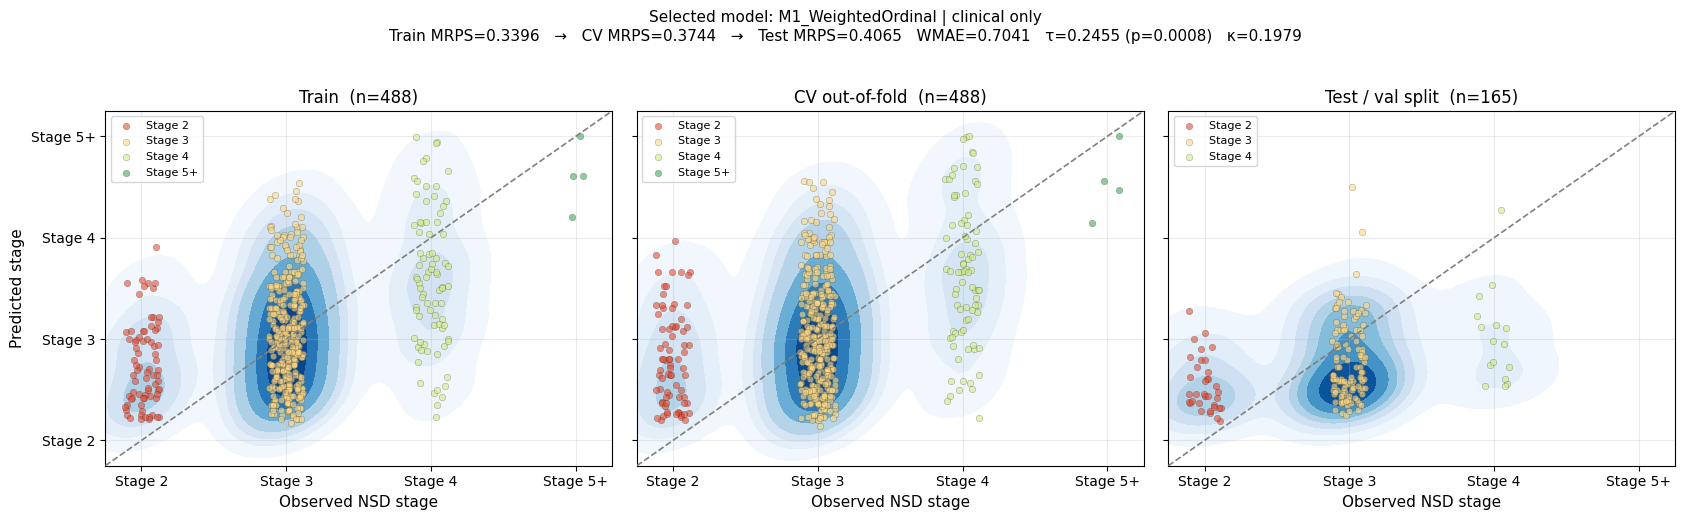

In [132]:
# ============================================================
# CHOOSE THE MODEL AND ABLATION TO VISUALIZE
# ============================================================

MODEL_TO_PLOT    = "M1_WeightedOrdinal"
ABLATION_TO_PLOT = "clinical only"

feat_cols = ABLATIONS[ABLATION_TO_PLOT]

plot_candidates = all_results.loc[
    (all_results["model"] == MODEL_TO_PLOT)
    & (all_results["ablation"] == ABLATION_TO_PLOT)
].copy()

if plot_candidates.empty:
    raise ValueError("No completed result was found for:\n"
                     f"Model: {MODEL_TO_PLOT}\nAblation: {ABLATION_TO_PLOT}")

# MRPS (macro ranked probability score) is a positive loss, so smaller is better.
# Sort on cv_mrps — test_mrps must never drive a selection decision.
best = plot_candidates.sort_values("cv_mrps", ascending=True).iloc[0]

print("Model being visualized:  ", best["model"])
print("Ablation:                ", best["ablation"])
print("Selected hyperparameters:", best["hp"])
print(f"CV MRPS (selection):      {best['cv_mrps']:.4f}")
print(f"Test MRPS (held-out val): {best['test_mrps']:.4f}")

# ── Refit with the EXACT kwargs recorded at selection time ────────────────
model_key = best["family"]
hp        = ast.literal_eval(best["hp_kwargs"])

y_tr_num = Y_TRAIN_NUM
y_v_num  = Y_VAL_NUM
classes  = CLASSES.copy()

pred_tr, pred_v, proba_tr, proba_v = _fit_predict(
    model_key, ord_train_fe, y_tr_num, ord_val_fe, y_v_num, feat_cols, hp)

if pred_tr is None:
    raise RuntimeError(f"Refit failed for {best['model']} | {best['ablation']}")

pred_tr = np.asarray(pred_tr, dtype=float)
pred_v  = np.asarray(pred_v,  dtype=float)

# ── NEW: recover the CV OOF (out-of-fold) predictions for this exact config ──
# cv_oof is cached by (family, feat_cols, hp), so this reuses the arrays that
# produced best["cv_mrps"] instead of refitting the folds. It returns arrays
# sized to ALL training rows; mask selects the rows that actually got scored
# out-of-fold (subjects pinned into every fold's TRAIN side are excluded).
_oof = cv_oof(model_key, feat_cols, hp)
if _oof is None:
    raise RuntimeError("cv_oof returned None for the selected configuration.")

oof_pred_full, oof_proba_full, oof_mask = _oof

y_oof_num = np.asarray(Y_TRAIN_NUM, dtype=float)[oof_mask]
pred_oof  = np.asarray(oof_pred_full,  dtype=float)[oof_mask]
proba_oof = np.asarray(oof_proba_full, dtype=float)[oof_mask]

print(f"\nOOF rows plotted: {oof_mask.sum()} / {len(oof_mask)} training rows "
      f"({len(oof_mask) - oof_mask.sum()} pinned, never held out)")

# ── Posterior-derived continuous predicted stages ────────────────────────
proba_tr = np.asarray(proba_tr, dtype=float)
proba_v  = np.asarray(proba_v,  dtype=float)
classes  = np.asarray(classes,  dtype=float)

for name, P in [("train", proba_tr), ("oof", proba_oof), ("val", proba_v)]:
    assert P.ndim == 2 and P.shape[1] == len(classes), f"{name} proba shape"
    assert np.allclose(P.sum(axis=1), 1.0, atol=1e-4), f"{name} rows do not sum to 1"

assert np.array_equal(classes, np.array([2.0, 3.0, 4.0, 5.0])), \
    f"Unexpected class order: {classes}"

# Expected stage: 2*P(Stage 2) + 3*P(Stage 3) + 4*P(Stage 4) + 5*P(Stage 5+)
posterior_stage_tr  = proba_tr  @ classes
posterior_stage_oof = proba_oof @ classes
posterior_stage_v   = proba_v   @ classes

print("Train posterior-stage range:      "
      f"{posterior_stage_tr.min():.3f} to {posterior_stage_tr.max():.3f}")
print("CV OOF posterior-stage range:     "
      f"{posterior_stage_oof.min():.3f} to {posterior_stage_oof.max():.3f}")
print("Validation posterior-stage range: "
      f"{posterior_stage_v.min():.3f} to {posterior_stage_v.max():.3f}")

# ── Metrics printout ───────────────────────────────────────────────────────
tr_m  = compute_metrics(y_tr_num,  pred_tr,  proba_tr,  classes, prefix="train_")
oof_m = compute_metrics(y_oof_num, pred_oof, proba_oof, classes, prefix="cv_")
v_m   = compute_metrics(y_v_num,   pred_v,   proba_v,   classes, prefix="test_")

# Sanity check: recomputed OOF metrics must reproduce the stored selection metric.
if not np.isclose(oof_m["cv_mrps"], float(best["cv_mrps"]), atol=1e-8):
    print(f"\n  ⚠  recomputed CV MRPS={oof_m['cv_mrps']:.6f} differs from stored "
          f"{float(best['cv_mrps']):.6f} — folds or features changed since selection.")

labels = {
    "rps":   "RPS (plain)",
    "mrps":  "RPS (macro)",
    "wmae":  "Weighted MAE",
    "tau":   "Kendall τ",
    "tau_p": "  τ p-value",
    "kappa": "Quadratic κ",
    "f1":    "Macro F1",
    "wacc":  "Weighted accuracy",
}
print(f"\n{'Metric':<22} {'Train':>10} {'CV (OOF)':>10} {'Test':>10}")
print("─" * 56)
for key, label in labels.items():
    print(f"  {label:<20} {tr_m[f'train_{key}']:>10.4f} "
          f"{oof_m[f'cv_{key}']:>10.4f} {v_m[f'test_{key}']:>10.4f}")

gap_fit = oof_m["cv_mrps"] - tr_m["train_mrps"]
gap_sel = v_m["test_mrps"] - oof_m["cv_mrps"]
if gap_fit > 0.05:
    print(f"\n  ⚠  train → cv MRPS gap = {gap_fit:+.3f} — overfitting to training rows.")
if gap_sel > 0.05:
    print(f"  ⚠  cv → test MRPS gap = {gap_sel:+.3f} — possible selection on CV noise.")

# ── Posterior-mean predicted-stage plot: Train / CV OOF / Test ────────────
stage_range = (1.75, 5.25)
ticks = [2, 3, 4, 5]

stage_tick_labels = {2: "Stage 2", 3: "Stage 3", 4: "Stage 4", 5: "Stage 5+"}
stage_colors = dict(zip(ticks, plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(ticks)))))

# Jitter is applied only to the observed stage on the x-axis.
jitter = 0.12
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=True, sharey=True)

fig.suptitle(
    f"Selected model: {best['model']} | {best['ablation']}\n"
    f"Train MRPS={tr_m['train_mrps']:.4f}   →   CV MRPS={oof_m['cv_mrps']:.4f}   →   "
    f"Test MRPS={v_m['test_mrps']:.4f}   "
    f"WMAE={v_m['test_wmae']:.4f}   "
    f"τ={v_m['test_tau']:.4f} (p={v_m['test_tau_p']:.4f})   "
    f"κ={v_m['test_kappa']:.4f}",
    fontsize=11,
    y=1.03,
)

for ax, y_true, expected_stage, split in [
    (axes[0], y_tr_num,  posterior_stage_tr,  f"Train  (n={len(y_tr_num)})"),
    (axes[1], y_oof_num, posterior_stage_oof, f"CV out-of-fold  (n={len(y_oof_num)})"),
    (axes[2], y_v_num,   posterior_stage_v,   f"Test / val split  (n={len(y_v_num)})"),
]:
    y_true = np.asarray(y_true, dtype=float)
    expected_stage = np.asarray(expected_stage, dtype=float)

    x_plot = y_true + rng.uniform(-jitter, jitter, size=len(y_true))

    sns.kdeplot(x=x_plot, y=expected_stage, fill=True, cmap="Blues",
                thresh=0.05, levels=8, ax=ax)

    for stage in ticks:
        mask = y_true == stage
        if not mask.any():
            continue
        ax.scatter(x_plot[mask], expected_stage[mask], color=stage_colors[stage],
                   edgecolor="black", linewidth=0.20, alpha=0.60, s=22,
                   label=stage_tick_labels[stage], zorder=3)

    lo, hi = stage_range
    ax.plot([lo, hi], [lo, hi], linestyle="--", color="gray", linewidth=1.2, zorder=4)
    ax.set_xlim(stage_range)
    ax.set_ylim(stage_range)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels([stage_tick_labels[x] for x in ticks])
    ax.set_yticklabels([stage_tick_labels[x] for x in ticks])
    ax.set_xlabel("Observed NSD stage", fontsize=11)
    ax.set_title(split, fontsize=12)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Predicted stage", fontsize=11)

plt.tight_layout()
plt.savefig("selected_model_posterior_mean_stage.png", dpi=150, bbox_inches="tight")
plt.show()

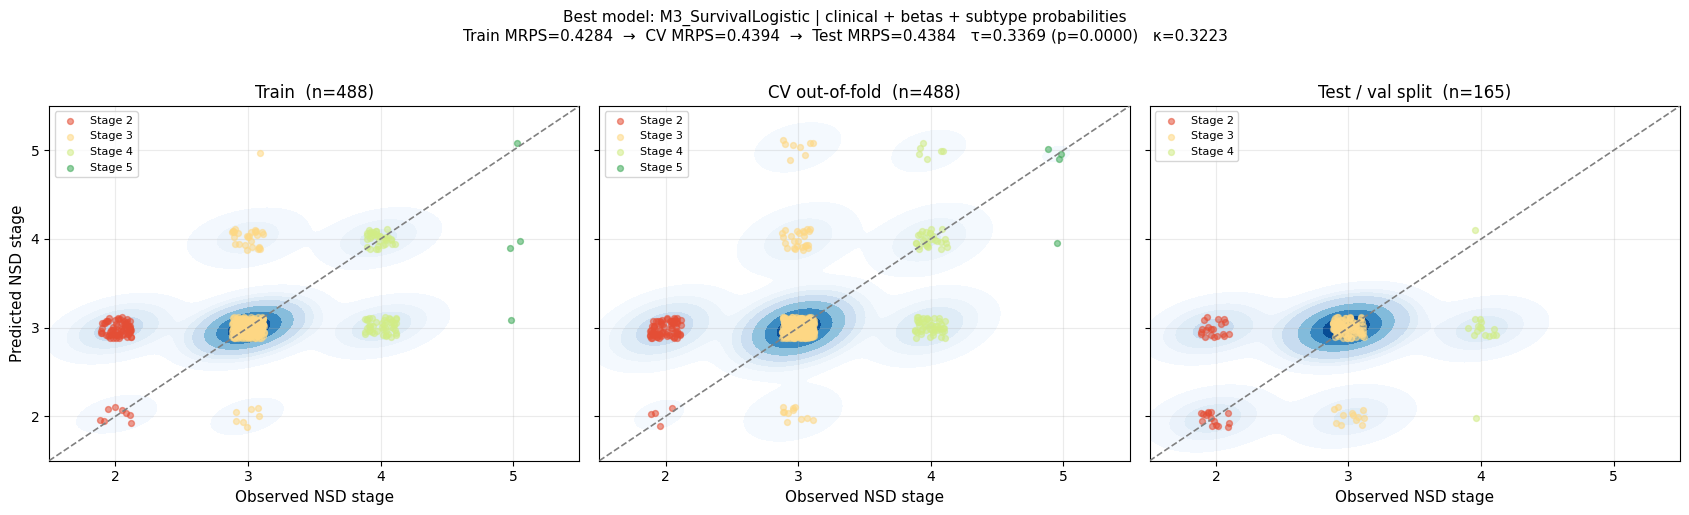

In [101]:
%matplotlib inline
pred_tr  = np.asarray(pred_tr,  dtype=float)
pred_oof = np.asarray(pred_oof, dtype=float)
pred_v   = np.asarray(pred_v,   dtype=float)

stage_range = (1.5, 5.5)
jitter = 0.12
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=True, sharey=True)
fig.suptitle(
    f"Best model: {best['model']} | {best['ablation']}\n"
    f"Train MRPS={tr_m['train_mrps']:.4f}  →  CV MRPS={oof_m['cv_mrps']:.4f}  →  "
    f"Test MRPS={v_m['test_mrps']:.4f}   "
    f"τ={v_m['test_tau']:.4f} (p={v_m['test_tau_p']:.4f})   "
    f"κ={v_m['test_kappa']:.4f}",
    fontsize=11, y=1.02,
)

lo, hi = stage_range

# All three panels share ONE stage list and ONE palette so that a colour means
# the same stage everywhere. Deriving stages per-panel from np.unique(y_true)
# silently recolours the plot whenever a split is missing a stage.
all_stages = [2.0, 3.0, 4.0, 5.0]
palette = dict(zip(all_stages, plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(all_stages)))))

for ax, y_true, y_pred, split in [
    (axes[0], y_tr_num,  pred_tr,  f"Train  (n={len(y_tr_num)})"),
    (axes[1], y_oof_num, pred_oof, f"CV out-of-fold  (n={len(y_oof_num)})"),
    (axes[2], y_v_num,   pred_v,   f"Test / val split  (n={len(y_v_num)})"),
]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    # Jitter both observed and predicted integer stages.
    x_plot = y_true + rng.uniform(-jitter, jitter, size=len(y_true))
    y_plot = y_pred + rng.uniform(-jitter, jitter, size=len(y_pred))

    sns.kdeplot(x=x_plot, y=y_plot, fill=True, cmap="Blues",
                thresh=0.05, levels=8, ax=ax)

    for stage in all_stages:
        mask = y_true == stage
        if not mask.any():
            continue
        ax.scatter(x_plot[mask], y_plot[mask], color=palette[stage], alpha=0.55, s=18,
                   label=f"Stage {int(stage)}", zorder=3)

    ax.plot([lo, hi], [lo, hi], linestyle="--", color="gray", linewidth=1.2, zorder=4)
    ax.set(xlim=(lo, hi), ylim=(lo, hi), xticks=all_stages, yticks=all_stages)
    ax.set_xlabel("Observed NSD stage", fontsize=11)
    ax.set_title(split, fontsize=12)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Predicted NSD stage", fontsize=11)

plt.tight_layout()
plt.savefig("best_model_kde.png", dpi=150, bbox_inches="tight")
plt.show()

In [102]:
np.savez(
    "selected_model_probabilities.npz",
    y_tr_num=np.asarray(y_tr_num),
    y_oof_num=np.asarray(y_oof_num),
    y_v_num=np.asarray(y_v_num),
    proba_tr=np.asarray(proba_tr),
    proba_oof=np.asarray(proba_oof),
    proba_v=np.asarray(proba_v),
    classes=np.asarray(classes),
)

In [103]:
saved = np.load("selected_model_probabilities.npz")

y_tr_num  = saved["y_tr_num"]
y_oof_num = saved["y_oof_num"]
y_v_num   = saved["y_v_num"]
proba_tr  = saved["proba_tr"]
proba_oof = saved["proba_oof"]
proba_v   = saved["proba_v"]
classes   = saved["classes"]

In [104]:
classes   = np.asarray(classes,   dtype=float)
y_tr_num  = np.asarray(y_tr_num,  dtype=float)
y_oof_num = np.asarray(y_oof_num, dtype=float)
y_v_num   = np.asarray(y_v_num,   dtype=float)

def _p_observed(y_num, proba):
    """Probability the model gave to the class that actually occurred."""
    idx = np.searchsorted(classes, y_num)
    assert np.array_equal(classes[idx], y_num), "label not found in classes"
    return proba[np.arange(len(y_num)), idx]

p_observed_tr  = _p_observed(y_tr_num,  proba_tr)
p_observed_oof = _p_observed(y_oof_num, proba_oof)
p_observed_v   = _p_observed(y_v_num,   proba_v)

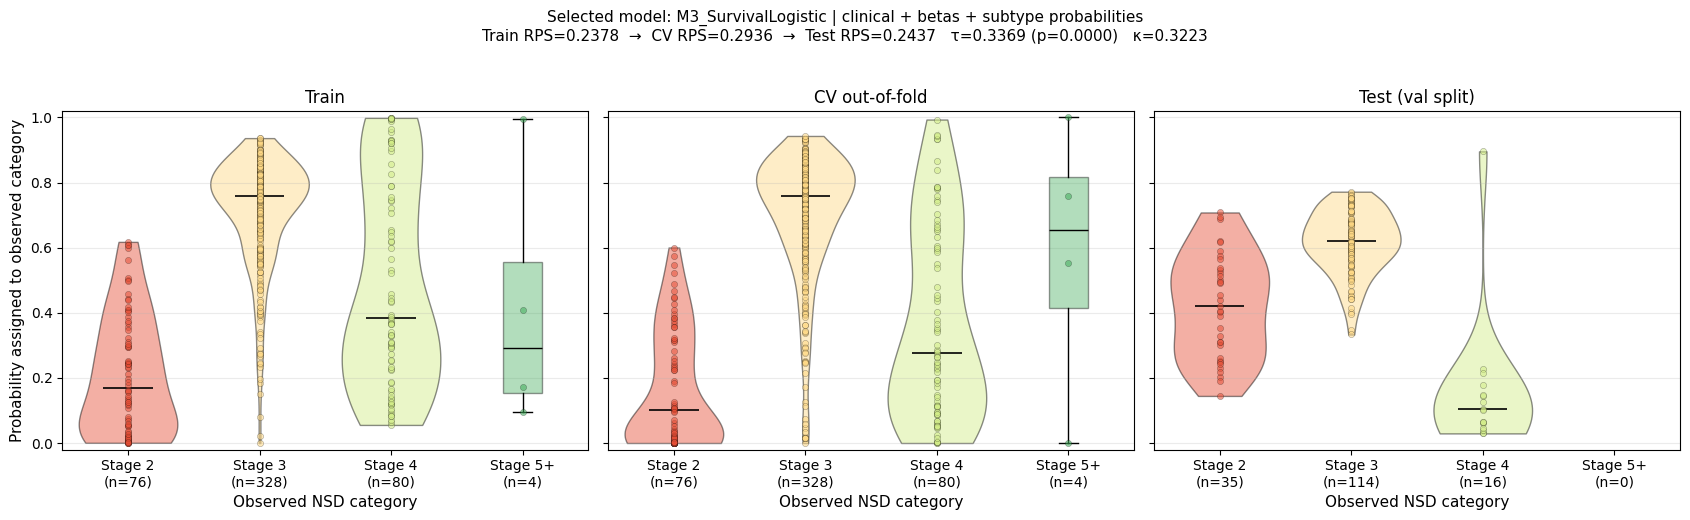

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

fig.suptitle(
    f"Selected model: {best['model']} | {best['ablation']}\n"
    f"Train RPS={tr_m['train_rps']:.4f}  →  CV RPS={oof_m['cv_rps']:.4f}  →  "
    f"Test RPS={v_m['test_rps']:.4f}   "
    f"τ={v_m['test_tau']:.4f} (p={v_m['test_tau_p']:.4f})   "
    f"κ={v_m['test_kappa']:.4f}",
    fontsize=11,
    y=1.03
)

for ax, y_true, p_observed, split in [
    (axes[0], y_tr_num,  p_observed_tr,  "Train"),
    (axes[1], y_oof_num, p_observed_oof, "CV out-of-fold"),
    (axes[2], y_v_num,   p_observed_v,   "Test (val split)"),
]:
    y_true = np.asarray(y_true, dtype=int)
    p_observed = np.asarray(p_observed, dtype=float)

    for stage in ticks:
        mask = y_true == stage
        stage_probabilities = p_observed[mask]
        n = int(mask.sum())
        x_position = ticks.index(stage)

        if n == 0:
            continue

        # Boxplot for very small stage groups, violin once there are ≥10 points.
        if n < 10:
            box = ax.boxplot(stage_probabilities, positions=[x_position],
                             widths=0.30, patch_artist=True, showfliers=False)
            box["boxes"][0].set(facecolor=stage_colors[stage], alpha=0.40)
            for median in box["medians"]:
                median.set_color("black")
        else:
            violin = ax.violinplot(stage_probabilities, positions=[x_position],
                                   widths=0.75, showmeans=False,
                                   showmedians=True, showextrema=False)
            for body in violin["bodies"]:
                body.set_facecolor(stage_colors[stage])
                body.set_edgecolor("black")
                body.set_alpha(0.45)
            violin["cmedians"].set_color("black")
            violin["cmedians"].set_linewidth(1.2)

        ax.scatter(np.full(n, x_position), stage_probabilities,
                   color=stage_colors[stage], edgecolor="black", linewidth=0.25,
                   alpha=0.55, s=20, zorder=3)

    counts = pd.Series(y_true).value_counts()
    xtick_labels = [f"{stage_tick_labels[stage]}\n(n={int(counts.get(stage, 0))})"
                    for stage in ticks]

    ax.set_xticks(range(len(ticks)))
    ax.set_xticklabels(xtick_labels)
    ax.set_xlim(-0.5, len(ticks) - 0.5)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("Observed NSD category", fontsize=11)
    ax.set_title(split, fontsize=12)
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Probability assigned to observed category", fontsize=11)

plt.tight_layout()
plt.savefig("selected_model_probability_density.png", dpi=150, bbox_inches="tight")
plt.show()

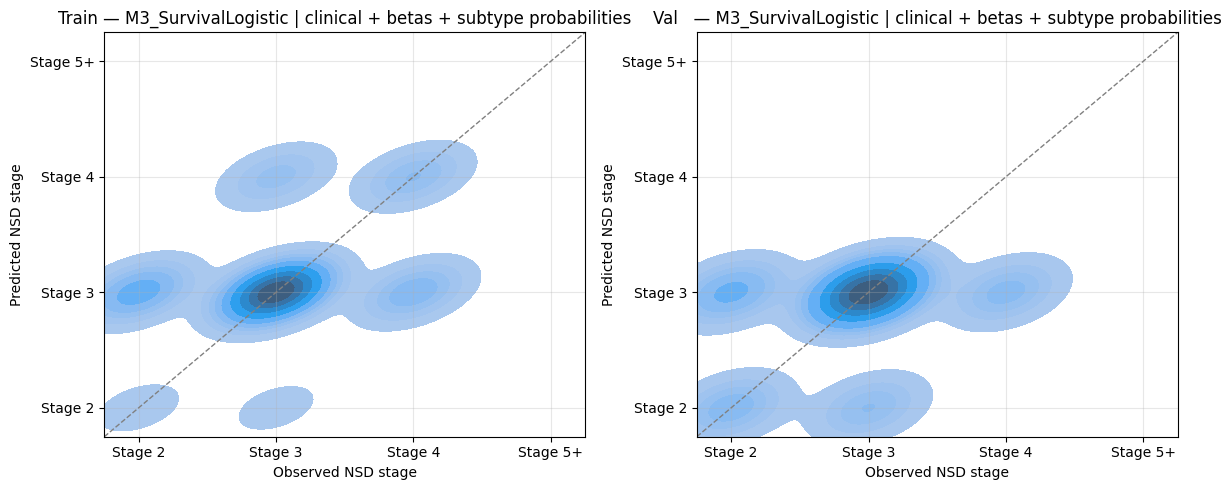

In [107]:
# ── Plain KDE plot ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, true, pred, title in [
    (axes[0], y_tr_num, pred_tr, f"Train — {best['model']} | {best['ablation']}"),
    (axes[1], y_v_num,  pred_v,  f"Val   — {best['model']} | {best['ablation']}"),
]:
    sns.kdeplot(x=true.astype(float), y=pred.astype(float), fill=True, ax=ax)
    lo, hi = 1.75, 5.25
    ax.plot([lo, hi], [lo, hi], ls="--", c="gray", lw=1)
    ax.set_xlabel("Observed NSD stage")
    ax.set_ylabel("Predicted NSD stage")
    ax.set_xlim(1.75, 5.25)
    ax.set_ylim(1.75, 5.25)
    ax.set_xticks([2, 3, 4, 5])
    ax.set_yticks([2, 3, 4, 5])
    ax.set_xticklabels(["Stage 2", "Stage 3", "Stage 4", "Stage 5+"])
    ax.set_yticklabels(["Stage 2", "Stage 3", "Stage 4", "Stage 5+"])
    ax.set_title(title)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("best_model_kde_plain.png", dpi=150, bbox_inches="tight")
plt.show()

In [108]:
notebook_elapsed = time.time() - notebook_start_time
hours = int(notebook_elapsed // 3600)
minutes = int((notebook_elapsed % 3600) // 60)
seconds = int(notebook_elapsed % 60)
print(f"Total notebook runtime: {hours}h {minutes}m {seconds}s")

Total notebook runtime: 1h 52m 40s


In [118]:
import os
import pandas as pd

CSV_PATH = "/home/aantar2/bme560_project/Ordinal_NSD_Predict_Results/ordinal_model_results_cv_stageweight.csv"

df = pd.read_csv(CSV_PATH)   # let pandas raise directly — no wrapper to mislead you

sort_col = "cv_mrps" if "cv_mrps" in df.columns else "val_mrps"
cols = [c for c in ["model", "ablation", "hp", "cv_mrps", "test_mrps", "test_wmae",
                    "cv_rps", "test_rps", "val_mrps", "val_rps",
                    "train_mrps", "test_tau", "test_f1"]
        if c in df.columns]

print("=" * 100)
print(f"{CSV_PATH}   ({len(df)} rows)")
print("=" * 100)

with pd.option_context("display.max_rows", None, "display.max_colwidth", 50,
                       "display.width", None, "display.float_format", "{:.4f}".format):
    display(df.sort_values(sort_col)[cols])

/home/aantar2/bme560_project/Ordinal_NSD_Predict_Results/ordinal_model_results_cv_stageweight.csv   (27 rows)


,model,ablation,hp,cv_mrps,test_mrps,test_wmae,cv_rps,test_rps,train_mrps,test_tau,test_f1
5,M1_WeightedOrdinal,clinical + subtype probabilities,"probit,bfgs",0.3723,0.4086,0.6979,0.4054,0.3311,0.3188,0.2167,0.3630
0,M1_WeightedOrdinal,clinical only,"probit,bfgs",0.3744,0.4065,0.7041,0.3889,0.3309,0.3396,0.2455,0.3505
4,M1_WeightedOrdinal,clinical + betas,"probit,bfgs",0.4080,0.4461,0.7916,0.4140,0.3420,0.3163,0.1123,0.2937
7,M1_WeightedOrdinal,clinical + betas + subtype probabilities,"probit,bfgs",0.4335,0.4463,0.7400,0.4331,0.3469,0.3101,0.1616,0.3370
2,M1_WeightedOrdinal,subtype probabilities only,"probit,bfgs",0.4640,0.4761,0.8982,0.4890,0.3613,0.4332,0.0301,0.2307
25,M4_SurvivalSVM,clinical + betas + subtype probabilities,"C=100.0,kernel=linear,gamma=scale,visit=False,...",0.4918,0.4807,0.6458,0.3049,0.2969,0.4991,0.1948,0.4047
1,M1_WeightedOrdinal,betas only,"probit,bfgs",0.4940,0.5478,0.9732,0.4827,0.3999,0.4248,-0.0248,0.2140
22,M4_SurvivalSVM,clinical + betas,"C=100.0,kernel=linear,gamma=scale,visit=False,...",0.4960,0.4646,0.6195,0.2907,0.2707,0.4378,0.2352,0.4355
14,M2_SurvivalAdaBoost,clinical + subtype probabilities,"n=200,lr=0.5,depth=3,loss=square,cal=prior,fra...",0.5104,0.5033,0.6667,0.2771,0.2598,0.6691,NaN,0.2724
9,M2_SurvivalAdaBoost,clinical only,"n=50,lr=0.5,depth=2,loss=square,cal=platt,frac...",0.5170,0.4875,0.6009,0.2852,0.2796,0.4280,0.2882,0.3910
